In [3]:
#import librarires

import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore') #hide unnecessary warnings
#for visualizations:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#set up for the plot style so charts look consistent
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")  #accessible colors
 
#Set default figure size (width=12 inches, height=6 inches)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#to get metrics for model performance
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay
 
#for t-tests
from scipy import stats

In [7]:
#Load the data from the CSV files I created
data_folder = "data/raw"

#list of our Statcast file names
statcast_files = [
    "statcast_2021_buffer.csv",
    "statcast_2022.csv",
    "statcast_2023.csv",
    "statcast_2024.csv",
    "statcast_2025.csv",
]
 
#load each file and store in a list
loaded_dataframes = []
 
for file_name in statcast_files:
    file_path = os.path.join(data_folder, file_name)
    
    #Check that the file exists before trying to load it
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, low_memory=False)
        loaded_dataframes.append(df)
        print(f"  Loaded {file_name}: {len(df):,} rows")
    else:
        print(f"  WARNING: {file_name} not found")
 
#Combine all the individual DataFrames into one big DataFrame
statcast = pd.concat(loaded_dataframes, ignore_index=True)
 
print(f"\nCombined Statcast data: {len(statcast):,} rows x {statcast.shape[1]} columns")

  Loaded statcast_2021_buffer.csv: 142,215 rows
  Loaded statcast_2022.csv: 739,180 rows
  Loaded statcast_2023.csv: 732,562 rows
  Loaded statcast_2024.csv: 745,349 rows
  Loaded statcast_2025.csv: 749,091 rows

Combined Statcast data: 3,108,397 rows x 118 columns


In [9]:
#load the IL Transaction Data ---
il_file_path = os.path.join(data_folder, "pitcher_il_transactions.csv")
il_df = pd.read_csv(il_file_path, parse_dates=["date", "effective_date"])
 
print(f"Pitcher IL transactions: {len(il_df):,} rows")
print(f"\nFirst few rows:")
print(il_df.head().to_string())
 

Pitcher IL transactions: 8,149 rows

First few rows:
   transaction_id       date effective_date                                                                           description  player_id player_name  team_id       team_name  year     action il_type              injury
0          615332 2022-04-15     2022-04-15  Detroit Tigers placed RHP Casey Mize on the 10-day injured list. Right elbow sprain.     663554  Casey Mize      116  Detroit Tigers  2022     placed  10-day  Right elbow sprain
1          625400 2022-05-31     2022-05-31  Detroit Tigers placed RHP Casey Mize on the 60-day injured list. Right elbow sprain.     663554  Casey Mize      116  Detroit Tigers  2022     placed  60-day  Right elbow sprain
2          659360 2022-11-10     2022-11-10                 Detroit Tigers activated RHP Casey Mize from the 60-day injured list.     663554  Casey Mize      116  Detroit Tigers  2022  activated  60-day                 NaN
3          671940 2023-02-17     2023-02-17  Detroit Ti

In [11]:
statcast["game_date"] = pd.to_datetime(statcast["game_date"]) #Convert to datetime format
 
print("Date column converted to datetime format.")
print(f"Date range: {statcast['game_date'].min()} to {statcast['game_date'].max()}")
 

Date column converted to datetime format.
Date range: 2021-09-01 00:00:00 to 2025-11-01 00:00:00


In [13]:
print("Game types before filtering:")
game_type_counts = statcast["game_type"].value_counts()
for game_type in game_type_counts.index:
    print(f"  {game_type}: {game_type_counts[game_type]:,} rows")
 
#Filter for egular season rows only since postseason workload patterns can be different.
statcast = statcast[statcast["game_type"] == "R"].copy()
 
print(f"\nAfter filtering to regular season only: {len(statcast):,} rows")

Game types before filtering:
  R: 2,986,052 rows
  S: 60,728 rows
  D: 24,651 rows
  L: 16,709 rows
  F: 11,274 rows
  W: 8,983 rows

After filtering to regular season only: 2,986,052 rows


In [15]:
#Get rid of any old columns that aren't being used
columns_to_drop = []
for col in statcast.columns:
    if "deprecated" in col.lower():
        columns_to_drop.append(col)
 
statcast = statcast.drop(columns=columns_to_drop)
 
print(f"Removed {len(columns_to_drop)} deprecated columns:")
for col in columns_to_drop:
    print(f"  - {col}")
 
#Add a season column to make it easy to group data by year later
statcast["season"] = statcast["game_date"].dt.year
 
print(f"\nSeasons in data: {sorted(statcast['season'].unique())}")
print(f"Total unique pitchers: {statcast['pitcher'].nunique()}")
 
#Look at a few important columns to make sure they look right
 
key_columns = [
    "game_date", "player_name", "pitcher", "pitch_type", "release_speed",
    "release_spin_rate", "pfx_x", "pfx_z", "game_type", "season"
]
 
print("Key columns preview:")
print(statcast[key_columns].head(10).to_string())
 
print(f"\nMissing values in key columns:")
for col in key_columns:
    missing = statcast[col].isna().sum()
    total = len(statcast)
    pct = round(missing / total * 100, 1)
    print(f"  {col}: {missing:,} missing ({pct}%)")

Removed 5 deprecated columns:
  - spin_rate_deprecated
  - break_angle_deprecated
  - break_length_deprecated
  - tfs_deprecated
  - tfs_zulu_deprecated

Seasons in data: [2021, 2022, 2023, 2024, 2025]
Total unique pitchers: 1592
Key columns preview:
       game_date       player_name  pitcher pitch_type  release_speed  release_spin_rate  pfx_x  pfx_z game_type  season
10852 2021-10-03       Smith, Will   519293         FF           92.3             2330.0   0.69   1.38         R    2021
10853 2021-10-03       Smith, Will   519293         SL           80.6             2254.0  -0.77   0.48         R    2021
10854 2021-10-03       Smith, Will   519293         CU           75.5             1940.0  -0.65  -0.51         R    2021
10855 2021-10-03       Smith, Will   519293         CU           75.0             2017.0  -0.69  -0.69         R    2021
10856 2021-10-03       Smith, Will   519293         FF           91.2             2281.0   0.63   1.28         R    2021
10857 2021-10-03       

Now that the data is looking good, I'm going to start aggregating data from the pitch level to game level summaries. I'm looking to create the following features:  
  
- For workload: Total pitches thrown, Number of innings pitched, Number of batters faced
- For velocity: Average fastball velocity, Max fastball velocity, Average velocity across all pitch types
- For Pitch mix: % of each pitch type, Number of different pitch types
- For movement: Avgerage horizontal break, Average vertical break, Average spin rate
- For context: Strike %, Ball %

In [19]:
#See what type of pitches
print("Pitch types in the data:")
pitch_type_counts = statcast["pitch_type"].value_counts()
for pt in pitch_type_counts.index:
    print(f"  {pt}: {pitch_type_counts[pt]:,}")

Pitch types in the data:
  FF: 966,002
  SL: 462,575
  SI: 461,930
  CH: 317,188
  FC: 231,722
  CU: 201,744
  ST: 177,161
  FS: 74,050
  KC: 59,158
  SV: 13,146
  FA: 3,964
  EP: 2,645
  FO: 1,470
  KN: 1,438
  CS: 590
  SC: 234
  PO: 195
  UN: 13


We'll count the following pitch types as 'Fastballs':  

- FF (four-seam fast ball)
- SI (sinker)
- FC (cutter)
- FA (fastball)

In [23]:
fastball_types = ["FF", "SI", "FC", "FA"]
 
print("Fastball types:", fastball_types)
 
#Check how many pitches fall into the fastball category
fastball_count = statcast[statcast["pitch_type"].isin(fastball_types)].shape[0]
total_count = len(statcast)
fastball_pct = round(fastball_count / total_count * 100, 1)
print(f"Fastball pitches: {fastball_count:,} out of {total_count:,} ({fastball_pct}%)")

Fastball types: ['FF', 'SI', 'FC', 'FA']
Fastball pitches: 1,663,618 out of 2,986,052 (55.7%)


In [25]:
#Now build out the game-level summary, group by pitcher ID and game date, then calculate metrics for each group
#Group by pitcher and game date

grouped = statcast.groupby(["pitcher", "game_date"])
 
### Workload

#Total pitches: count the rows in each group
pitches_per_game = grouped.size()
pitches_per_game.name = "total_pitches"
 
#Batters faced: count unique at-bat numbers
batters_faced = grouped["at_bat_number"].nunique()
batters_faced.name = "batters_faced"
 
#Innings pitched: the max inning the pitcher appeared in gives us an estimate
max_inning = grouped["inning"].max()
max_inning.name = "max_inning"
 
print("Workload metrics calculated")
 
#Velocity

#Average velocity across all pitches
avg_velocity = grouped["release_speed"].mean()
avg_velocity.name = "avg_velocity"
 
#Max velocity across all pitches
max_velocity = grouped["release_speed"].max()
max_velocity.name = "max_velocity"
 
#Fastball-only velocity
# First, filter statcast to only fastballs
fastballs_only = statcast[statcast["pitch_type"].isin(fastball_types)]
fb_grouped = fastballs_only.groupby(["pitcher", "game_date"])
 
avg_fb_velocity = fb_grouped["release_speed"].mean()
avg_fb_velocity.name = "avg_fb_velocity"
 
max_fb_velocity = fb_grouped["release_speed"].max()
max_fb_velocity.name = "max_fb_velocity"
 
print("Velocity metrics calculated")
 
#Movement

# Average horizontal break
avg_pfx_x = grouped["pfx_x"].mean()
avg_pfx_x.name = "avg_pfx_x"
 
# Average vertical break
avg_pfx_z = grouped["pfx_z"].mean()
avg_pfx_z.name = "avg_pfx_z"
 
# Average spin rate
avg_spin = grouped["release_spin_rate"].mean()
avg_spin.name = "avg_spin_rate"
 
print("Movement metrics calculated")
 
#Pitch mix

# Number of different pitch types used
pitch_type_count = grouped["pitch_type"].nunique()
pitch_type_count.name = "num_pitch_types"
 
print("Pitch mix metrics calculated")
 
#Strike/Ball

#The "type" column tells us: S = strike, B = ball, X = in play
# Strike percentage = (strikes + in_play) / total_pitches
 
strike_counts = statcast[statcast["type"] == "S"].groupby(["pitcher", "game_date"]).size()
strike_counts.name = "strike_count"
 
ball_counts = statcast[statcast["type"] == "B"].groupby(["pitcher", "game_date"]).size()
ball_counts.name = "ball_count"
 
in_play_counts = statcast[statcast["type"] == "X"].groupby(["pitcher", "game_date"]).size()
in_play_counts.name = "in_play_count"
 
print("Strike/ball metrics calculated")
 
print("\nAll metrics ready. Combine into one DataFrame")
 
# Start with pitches per game as our base
game_summary = pd.DataFrame(pitches_per_game)
 
# Add each metric one at a time
game_summary["batters_faced"] = batters_faced
game_summary["max_inning"] = max_inning
game_summary["avg_velocity"] = avg_velocity
game_summary["max_velocity"] = max_velocity
game_summary["avg_fb_velocity"] = avg_fb_velocity
game_summary["max_fb_velocity"] = max_fb_velocity
game_summary["avg_pfx_x"] = avg_pfx_x
game_summary["avg_pfx_z"] = avg_pfx_z
game_summary["avg_spin_rate"] = avg_spin
game_summary["num_pitch_types"] = pitch_type_count
game_summary["strike_count"] = strike_counts
game_summary["ball_count"] = ball_counts
game_summary["in_play_count"] = in_play_counts
 
#Fill missing values with 0 for count columns
game_summary["strike_count"] = game_summary["strike_count"].fillna(0)
game_summary["ball_count"] = game_summary["ball_count"].fillna(0)
game_summary["in_play_count"] = game_summary["in_play_count"].fillna(0)
 
#Calculate strike percentage
game_summary["strike_pct"] = (
    game_summary["strike_count"] / game_summary["total_pitches"]
)
 
#Reset the index so pitcher and game_date become regular columns
game_summary = game_summary.reset_index()
 
#Add season column
game_summary["season"] = game_summary["game_date"].dt.year
 
print(f"Per-game summary created: {len(game_summary):,} rows x {game_summary.shape[1]} columns")
print(f"\nThis means {len(game_summary):,} pitcher-game appearances across all seasons.")
 
#Check the results
print("Columns in game_summary:")
for col in game_summary.columns:
    print(f"  {col}")
 
print(f"\nFirst 10 rows:")
print(game_summary.head(10).to_string())

Workload metrics calculated
Velocity metrics calculated
Movement metrics calculated
Pitch mix metrics calculated
Strike/ball metrics calculated

All metrics ready. Combine into one DataFrame
Per-game summary created: 87,251 rows x 18 columns

This means 87,251 pitcher-game appearances across all seasons.
Columns in game_summary:
  pitcher
  game_date
  total_pitches
  batters_faced
  max_inning
  avg_velocity
  max_velocity
  avg_fb_velocity
  max_fb_velocity
  avg_pfx_x
  avg_pfx_z
  avg_spin_rate
  num_pitch_types
  strike_count
  ball_count
  in_play_count
  strike_pct
  season

First 10 rows:
   pitcher  game_date  total_pitches  batters_faced  max_inning  avg_velocity  max_velocity  avg_fb_velocity  max_fb_velocity  avg_pfx_x  avg_pfx_z  avg_spin_rate  num_pitch_types  strike_count  ball_count  in_play_count  strike_pct  season
0   405395 2022-05-15             27              7           9     59.692593          69.6        62.373684             69.6  -0.125185   1.222222    1598

In [29]:
# Add pitch mix percentages

#Count how many of each pitch type each pitcher threw per game
pitch_type_by_game = statcast.groupby(["pitcher", "game_date", "pitch_type"]).size()
pitch_type_by_game.name = "count"
pitch_type_by_game = pitch_type_by_game.reset_index()

#Get total pitches per pitcher per game 
pitch_type_by_game = pitch_type_by_game.merge(
    game_summary[["pitcher", "game_date", "total_pitches"]],
    on=["pitcher", "game_date"],
    how="left"
)

#Calculate percentage
pitch_type_by_game["pct"] = pitch_type_by_game["count"] / pitch_type_by_game["total_pitches"]
 
#Pivot so each pitch type gets its own column
pitch_mix = pitch_type_by_game.pivot_table(
    index=["pitcher", "game_date"],
    columns="pitch_type",
    values="pct",
    fill_value=0
)
 
#Rename columns to make them clearer
new_column_names = {}
for col in pitch_mix.columns:
    new_column_names[col] = "pct_" + col
 
pitch_mix = pitch_mix.rename(columns=new_column_names)
pitch_mix = pitch_mix.reset_index()
 
# Step 5: Merge pitch mix into our game summary
game_summary = game_summary.merge(
    pitch_mix,
    on=["pitcher", "game_date"],
    how="left"
)
 
#Also add a combined fastball percentage column for convenience
fb_pct_cols = []
for col in game_summary.columns:
    # Check if this column is a fastball pitch type percentage
    for fb_type in fastball_types:
        if col == "pct_" + fb_type:
            fb_pct_cols.append(col)
 
#Sum up all fastball type percentages
game_summary["pct_fastball_all"] = game_summary[fb_pct_cols].sum(axis=1)
 
print(f"Pitch mix columns added. Game summary now has {game_summary.shape[1]} columns.")
print(f"\nPitch mix columns:")
for col in game_summary.columns:
    if col.startswith("pct_"):
        avg_val = game_summary[col].mean()
        print(f"  {col}: avg = {avg_val:.1%}")

Pitch mix columns added. Game summary now has 37 columns.

Pitch mix columns:
  pct_CH: avg = 8.8%
  pct_CS: avg = 0.0%
  pct_CU: avg = 5.3%
  pct_EP: avg = 0.2%
  pct_FA: avg = 0.3%
  pct_FC: avg = 7.3%
  pct_FF: avg = 31.6%
  pct_FO: avg = 0.0%
  pct_FS: avg = 2.4%
  pct_KC: avg = 1.7%
  pct_KN: avg = 0.0%
  pct_PO: avg = 0.0%
  pct_SC: avg = 0.0%
  pct_SI: avg = 16.9%
  pct_SL: avg = 17.7%
  pct_ST: avg = 6.8%
  pct_SV: avg = 0.3%
  pct_UN: avg = 0.0%
  pct_fastball_all: avg = 56.1%


In [31]:
#Saving the game-level data so we can use this for next steps
game_summary.to_csv("data/raw/game_summary.csv", index=False)
print(f"Game summary saved: {len(game_summary):,} rows")
print(f"  Columns: {game_summary.shape[1]}")
print(f"  Date range: {game_summary['game_date'].min()} to {game_summary['game_date'].max()}")

Game summary saved: 87,251 rows
  Columns: 37
  Date range: 2021-09-01 00:00:00 to 2025-09-28 00:00:00


Ok now we can start buildling the snapshots for 30-days pre injury... I'm trying to see what each pitcher's workload and mechanics looked like 30 days prior to when they got hurt.  
I'm going to turn each IL placement into an 'injured' row, an dcalculate the features I listed earlier for each 30-day window.

In [33]:
#Load the IL data we cleaned earlier
il_df = pd.read_csv("data/raw/pitcher_il_transactions.csv", parse_dates=["date", "effective_date"])
 
#We only care about IL PLACEMENTS (not activations)
placements = il_df[il_df["action"] == "placed"].copy()
 
print(f"Total IL placements (2022-2025): {len(placements)}")
print(f"Unique pitchers: {placements['player_id'].nunique()}")
 
#check
print(f"\nSample placements:")
print(placements[["date", "player_id", "player_name", "il_type", "injury"]].head(10).to_string())
 

Total IL placements (2022-2025): 4161
Unique pitchers: 1533

Sample placements:
         date  player_id       player_name il_type                     injury
0  2022-04-15     663554        Casey Mize  10-day         Right elbow sprain
1  2022-05-31     663554        Casey Mize  60-day         Right elbow sprain
3  2023-02-17     663554        Casey Mize  60-day         Right elbow injury
5  2024-07-03     663554        Casey Mize  60-day                        NaN
6  2024-07-03     663554        Casey Mize  15-day      Left hamstring strain
8  2025-05-10     663554        Casey Mize  15-day      Left hamstring strain
10 2022-08-31     663556  Shane McClanahan  15-day  Left shoulder impingement
12 2023-07-01     663556  Shane McClanahan  15-day         Mid-back tightness
14 2023-08-03     663556  Shane McClanahan  15-day     Left forearm tightness
17 2024-02-14     663556  Shane McClanahan  60-day         Tommy John surgery


Now for each placement, find all games the pitcher pitched in the 30 days before IL date, aggregate those games into a single row summary, and label it as 'injured', which will be our target variable =1

In [37]:
#This list will hold one feature row per IL placement
injured_snapshots = []
 
#Count how many placements we skip due to insufficient data
skipped_no_games = 0
skipped_too_few = 0
 
for i in range(len(placements)):
    #Get info about this IL placement
    row = placements.iloc[i]
    pitcher_id = row["player_id"]
    il_date = row["date"]
    
    #Define the 30-day lookback window
    window_start = il_date - timedelta(days=30)
    window_end = il_date
    
    #Find all games this pitcher had in the 30-day window
    #  Same pitcher
    #  Game date is on or after the window start
    #  Game date is before the IL date
    pitcher_games = game_summary[
        (game_summary["pitcher"] == pitcher_id) &
        (game_summary["game_date"] >= window_start) &
        (game_summary["game_date"] < window_end)
    ]
    
    #Check if we have enough data
    num_games = len(pitcher_games)
    
    if num_games == 0:
        skipped_no_games = skipped_no_games + 1
        continue
    
    if num_games < 2:
        skipped_too_few = skipped_too_few + 1
        #Flag this incase we need to deal with it later
    
    #Workload
    total_pitches_30d = pitcher_games["total_pitches"].sum()
    num_games_30d = num_games
    avg_pitches_per_game = pitcher_games["total_pitches"].mean()
    total_batters_30d = pitcher_games["batters_faced"].sum()
    
    #Velocity
    avg_fb_velo_30d = pitcher_games["avg_fb_velocity"].mean()
    avg_velo_30d = pitcher_games["avg_velocity"].mean()
    max_fb_velo_30d = pitcher_games["max_fb_velocity"].max()
    
    #Velocity trend: compare first half vs second half of the 30 day window
    #A negative trend means velocity is dropping — maybe a warning sign?
    if num_games >= 4:
        halfway = num_games // 2
        #Sort by date to get chronological order
        sorted_games = pitcher_games.sort_values("game_date")
        first_half_velo = sorted_games["avg_fb_velocity"].iloc[:halfway].mean()
        second_half_velo = sorted_games["avg_fb_velocity"].iloc[halfway:].mean()
        velo_trend = second_half_velo - first_half_velo
    else:
        velo_trend = 0  #Not enough games to calculate a trend
    
    #Movement
    avg_spin_30d = pitcher_games["avg_spin_rate"].mean()
    avg_pfx_x_30d = pitcher_games["avg_pfx_x"].mean()
    avg_pfx_z_30d = pitcher_games["avg_pfx_z"].mean()
    
    #Pitch mix
    avg_num_pitch_types = pitcher_games["num_pitch_types"].mean()
    avg_fb_pct = pitcher_games["pct_fastball_all"].mean()
    
    #Strike percentage
    avg_strike_pct = pitcher_games["strike_pct"].mean()
    
    #Rest (average days between appearances)
    if num_games >= 2:
        sorted_dates = pitcher_games["game_date"].sort_values()
        #Calculate days between each consecutive appearance
        days_between = sorted_dates.diff().dt.days
        #The first value will be NaN (no previous game), so skip
        avg_days_rest = days_between.iloc[1:].mean()
    else:
        avg_days_rest = 0  # Only one game, can't calculate rest
    

    snapshot = {
        #Player Identifiers
        "pitcher": pitcher_id,
        "player_name": row["player_name"],
        "il_date": il_date,
        "il_type": row["il_type"],
        "injury": row["injury"],
        
        #Workload features
        "total_pitches_30d": total_pitches_30d,
        "num_games_30d": num_games_30d,
        "avg_pitches_per_game": round(avg_pitches_per_game, 1),
        "total_batters_30d": total_batters_30d,
        
        #Velocity features
        "avg_fb_velo_30d": round(avg_fb_velo_30d, 1) if pd.notna(avg_fb_velo_30d) else None,
        "avg_velo_30d": round(avg_velo_30d, 1),
        "max_fb_velo_30d": round(max_fb_velo_30d, 1) if pd.notna(max_fb_velo_30d) else None,
        "velo_trend": round(velo_trend, 2),
        
        #Movement features
        "avg_spin_30d": round(avg_spin_30d, 1) if pd.notna(avg_spin_30d) else None,
        "avg_pfx_x_30d": round(avg_pfx_x_30d, 2),
        "avg_pfx_z_30d": round(avg_pfx_z_30d, 2),
        
        #Pitch mix features
        "avg_num_pitch_types": round(avg_num_pitch_types, 1),
        "avg_fb_pct": round(avg_fb_pct, 3),
        
        #Other
        "avg_strike_pct": round(avg_strike_pct, 3),
        "avg_days_rest": round(avg_days_rest, 1) if pd.notna(avg_days_rest) else None,
        
        #Target variable: this pitcher WAS injured
        "injured": 1
    }
    
    injured_snapshots.append(snapshot)
    
    #Print progress every 500 placements
    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1}/{len(placements)} placements...")
 
#Convert to DataFrame
injured_df = pd.DataFrame(injured_snapshots)
 
print(f"\nResults:")
print(f"  IL placements processed: {len(placements)}")
print(f"  Snapshots created: {len(injured_df)}")
print(f"  Skipped (no games in window): {skipped_no_games}")
print(f"  Had only 1 game in window: {skipped_too_few}")
 
#Preview the injured snapshots
print("Injured snapshot preview:")
print("-" * 80)
print(injured_df.head(10).to_string())
 
#Quick stats on the injured group
print("Injured Pitcher 30-Day Snapshot Statistics:")
print("-" * 50)
 
feature_cols = [
    "total_pitches_30d", "num_games_30d", "avg_pitches_per_game",
    "avg_fb_velo_30d", "velo_trend", "avg_spin_30d",
    "avg_fb_pct", "avg_strike_pct", "avg_days_rest"
]
 
for col in feature_cols:
    mean_val = injured_df[col].mean()
    median_val = injured_df[col].median()
    print(f"  {col}:")
    print(f"    Mean = {mean_val:.2f}, Median = {median_val:.2f}")

# Save the injured snapshots
injured_df.to_csv("data/raw/injured_snapshots.csv", index=False)
print(f"Saved {len(injured_df)} injured snapshots to data/raw/injured_snapshots.csv")

  Processed 500/4161 placements...
  Processed 1000/4161 placements...
  Processed 1500/4161 placements...
  Processed 2000/4161 placements...
  Processed 4000/4161 placements...

Results:
  IL placements processed: 4161
  Snapshots created: 1630
  Skipped (no games in window): 2531
  Had only 1 game in window: 160
Injured snapshot preview:
--------------------------------------------------------------------------------
   pitcher       player_name    il_date il_type                     injury  total_pitches_30d  num_games_30d  avg_pitches_per_game  total_batters_30d  avg_fb_velo_30d  avg_velo_30d  max_fb_velo_30d  velo_trend  avg_spin_30d  avg_pfx_x_30d  avg_pfx_z_30d  avg_num_pitch_types  avg_fb_pct  avg_strike_pct  avg_days_rest  injured
0   663554        Casey Mize 2022-04-15  10-day         Right elbow sprain                169              2                  84.5                 45             93.4          89.1             95.6        0.00        1845.8          -0.37           

A lot of skpped placements (2,531) show pitchers who went on the IL without pitching in the 30 days pirior, which could indicate injury during spring training, repeat IL stints, or offseason placements. We are left with 1,630 usable snapshots, which should be a decent sample size for modeling.  

Next, I'm going to create a 'Healthy' control group, so we can train a model with 'not injured' examples.  
To do this, I will find pitchers that didn't go on the IL that season, and pick a random date during the season for each healthy picher- then look back 30 days from then to compute the same features as I did for the injured group. I will label these as 'injured = 0'. I'm hoping to get at least the same number of snapshots to keep the classes balanced.


In [42]:
## Identify healthy pitchers per season

#For each season, figure out which pitchers were injured vs healthy
seasons = [2022, 2023, 2024, 2025]
 
for season in seasons:
    # Pitchers who were placed on IL this season
    season_placements = placements[placements["date"].dt.year == season]
    injured_ids = season_placements["player_id"].unique()
    
    # Pitchers who pitched this season
    season_games = game_summary[game_summary["season"] == season]
    all_pitcher_ids = season_games["pitcher"].unique()
    
    #Healthy pitchers = pitched this season but NOT on IL
    healthy_ids = []
    for pid in all_pitcher_ids:
        if pid not in injured_ids:
            healthy_ids.append(pid)
    
    print(f"{season}:")
    print(f"  Total pitchers who pitched: {len(all_pitcher_ids)}")
    print(f"  Placed on IL: {len(injured_ids)}")
    print(f"  Stayed healthy: {len(healthy_ids)}")

2022:
  Total pitchers who pitched: 871
  Placed on IL: 810
  Stayed healthy: 426
2023:
  Total pitchers who pitched: 863
  Placed on IL: 782
  Stayed healthy: 431
2024:
  Total pitchers who pitched: 855
  Placed on IL: 701
  Stayed healthy: 444
2025:
  Total pitchers who pitched: 873
  Placed on IL: 694
  Stayed healthy: 452


In [46]:
# Now create the random 30 day windows for each healthy pitcher

#set a random seed so results are reproducible
np.random.seed(42)

#Aiming for roughly the same number of healthy snapshots as injured ones
target_healthy = len(injured_df) * 2
print(f"Injured snapshots: {len(injured_df)}")
print(f"Target healthy snapshots: ~{target_healthy}")

seasons = [2022, 2023, 2024, 2025]

healthy_snapshots = []

for season in seasons:
    print(f"\n{season} — Source 1 (fully healthy pitchers):")

    #get this season's data
    season_games = game_summary[game_summary["season"] == season]
    season_placements = placements[placements["date"].dt.year == season]
    injured_ids = season_placements["player_id"].unique()
    
    # find pitchers who stayed healthy all season
    all_pitcher_ids = season_games["pitcher"].unique()
    healthy_ids = []
    for pid in all_pitcher_ids:
        if pid not in injured_ids:
            healthy_ids.append(pid)

    print(f"  Healthy pitchers available: {len(healthy_ids)}")

    snapshots_created = 0

    for pitcher_id in healthy_ids:
        #Get this pitcher's games
        pitcher_games = season_games[season_games["pitcher"] == pitcher_id]

        if len(pitcher_games) < 3:
            continue

        #find valid dates (at least 30 days after first game)
        sorted_dates = pitcher_games["game_date"].sort_values()
        first_game = sorted_dates.iloc[0]
        earliest_valid = first_game + timedelta(days=30)
        valid_dates = sorted_dates[sorted_dates >= earliest_valid]

        if len(valid_dates) == 0:
            continue
            
        # Pick 1  random date for this pitcher
        random_index = np.random.randint(0, len(valid_dates))
        random_date = valid_dates.iloc[random_index]
        
        # Compute 30-day window
        window_start = random_date - timedelta(days=30)
        window_games = pitcher_games[
            (pitcher_games["game_date"] >= window_start) &
            (pitcher_games["game_date"] < random_date)
        ]
        
        if len(window_games) == 0:
            continue

        num_games = len(window_games)

        #Calculate features like we did for injured pitchers
        total_pitches_30d = window_games["total_pitches"].sum()
        avg_pitches_per_game = window_games["total_pitches"].mean()
        total_batters_30d = window_games["batters_faced"].sum()

        avg_fb_velo_30d = window_games["avg_fb_velocity"].mean()
        avg_velo_30d = window_games["avg_velocity"].mean()
        max_fb_velo_30d = window_games["max_fb_velocity"].max()

        if num_games >= 4:
            halfway = num_games // 2
            sorted_window = window_games.sort_values("game_date")
            first_half = sorted_window["avg_fb_velocity"].iloc[:halfway].mean()
            second_half = sorted_window["avg_fb_velocity"].iloc[halfway:].mean()
            velo_trend = second_half - first_half
        else:
            velo_trend = 0

        avg_spin_30d = window_games["avg_spin_rate"].mean()
        avg_pfx_x_30d = window_games["avg_pfx_x"].mean()
        avg_pfx_z_30d = window_games["avg_pfx_z"].mean()
        avg_num_pitch_types = window_games["num_pitch_types"].mean()
        avg_fb_pct = window_games["pct_fastball_all"].mean()
        avg_strike_pct = window_games["strike_pct"].mean()
        
        if num_games >= 2:
            sorted_d = window_games["game_date"].sort_values()
            days_between = sorted_d.diff().dt.days
            avg_days_rest = days_between.iloc[1:].mean()
        else:
            avg_days_rest = 0
        
        snapshot = {
            "pitcher": pitcher_id,
            "player_name": "",
            "il_date": random_date,
            "il_type": "none",
            "injury": "none",
            "total_pitches_30d": total_pitches_30d,
            "num_games_30d": num_games,
            "avg_pitches_per_game": round(avg_pitches_per_game, 1),
            "total_batters_30d": total_batters_30d,
            "avg_fb_velo_30d": round(avg_fb_velo_30d, 1) if pd.notna(avg_fb_velo_30d) else None,
            "avg_velo_30d": round(avg_velo_30d, 1),
            "max_fb_velo_30d": round(max_fb_velo_30d, 1) if pd.notna(max_fb_velo_30d) else None,
            "velo_trend": round(velo_trend, 2),
            "avg_spin_30d": round(avg_spin_30d, 1) if pd.notna(avg_spin_30d) else None,
            "avg_pfx_x_30d": round(avg_pfx_x_30d, 2),
            "avg_pfx_z_30d": round(avg_pfx_z_30d, 2),
            "avg_num_pitch_types": round(avg_num_pitch_types, 1),
            "avg_fb_pct": round(avg_fb_pct, 3),
            "avg_strike_pct": round(avg_strike_pct, 3),
            "avg_days_rest": round(avg_days_rest, 1) if pd.notna(avg_days_rest) else None,
            "injured": 0
        }
        healthy_snapshots.append(snapshot)
        snapshots_created = snapshots_created + 1
    
    print(f"  Snapshots created: {snapshots_created}")
 
print(f"\nSource 1 total: {len(healthy_snapshots)} healthy snapshots")
 
source2_count = 0
 
for season in seasons:
    print(f"\n{season} — Source 2 (healthy periods from injured pitchers):")
    
    season_games = game_summary[game_summary["season"] == season]
    season_placements = placements[placements["date"].dt.year == season]
    
    snapshots_created = 0
    
    #go through each IL placement this season
    for i in range(len(season_placements)):
        row = season_placements.iloc[i]
        pitcher_id = row["player_id"]
        il_date = row["date"]
        
        #Get this pitcher's games this season
        pitcher_games = season_games[season_games["pitcher"] == pitcher_id]
        
        if len(pitcher_games) < 5:
            continue
        
        #The "danger zone" is the 30 days before the IL date
        danger_zone_start = il_date - timedelta(days=30)
        
        #find games that are before the danger zone
        safe_games = pitcher_games[pitcher_games["game_date"] < danger_zone_start]
        
        if len(safe_games) < 2:
            continue
        
        #Pick a random date from the safe games
        sorted_safe = safe_games["game_date"].sort_values()
        first_safe = sorted_safe.iloc[0]
        earliest_valid = first_safe + timedelta(days=30)
        valid_safe = sorted_safe[sorted_safe >= earliest_valid]
        
        if len(valid_safe) == 0:
            continue
        
        random_index = np.random.randint(0, len(valid_safe))
        random_date = valid_safe.iloc[random_index]
        
        #get 30-day window
        window_start = random_date - timedelta(days=30)
        window_games = safe_games[
            (safe_games["game_date"] >= window_start) &
            (safe_games["game_date"] < random_date)
        ]
        
        if len(window_games) == 0:
            continue
        
        num_games = len(window_games)
        
        #Calculate features
        total_pitches_30d = window_games["total_pitches"].sum()
        avg_pitches_per_game = window_games["total_pitches"].mean()
        total_batters_30d = window_games["batters_faced"].sum()
        
        avg_fb_velo_30d = window_games["avg_fb_velocity"].mean()
        avg_velo_30d = window_games["avg_velocity"].mean()
        max_fb_velo_30d = window_games["max_fb_velocity"].max()
        
        if num_games >= 4:
            halfway = num_games // 2
            sorted_window = window_games.sort_values("game_date")
            first_half = sorted_window["avg_fb_velocity"].iloc[:halfway].mean()
            second_half = sorted_window["avg_fb_velocity"].iloc[halfway:].mean()
            velo_trend = second_half - first_half
        else:
            velo_trend = 0
        
        avg_spin_30d = window_games["avg_spin_rate"].mean()
        avg_pfx_x_30d = window_games["avg_pfx_x"].mean()
        avg_pfx_z_30d = window_games["avg_pfx_z"].mean()
        avg_num_pitch_types = window_games["num_pitch_types"].mean()
        avg_fb_pct = window_games["pct_fastball_all"].mean()
        avg_strike_pct = window_games["strike_pct"].mean()
        
        if num_games >= 2:
            sorted_d = window_games["game_date"].sort_values()
            days_between = sorted_d.diff().dt.days
            avg_days_rest = days_between.iloc[1:].mean()
        else:
            avg_days_rest = 0
        
        snapshot = {
            "pitcher": pitcher_id,
            "player_name": row["player_name"],
            "il_date": random_date,
            "il_type": "none",
            "injury": "none",
            "total_pitches_30d": total_pitches_30d,
            "num_games_30d": num_games,
            "avg_pitches_per_game": round(avg_pitches_per_game, 1),
            "total_batters_30d": total_batters_30d,
            "avg_fb_velo_30d": round(avg_fb_velo_30d, 1) if pd.notna(avg_fb_velo_30d) else None,
            "avg_velo_30d": round(avg_velo_30d, 1),
            "max_fb_velo_30d": round(max_fb_velo_30d, 1) if pd.notna(max_fb_velo_30d) else None,
            "velo_trend": round(velo_trend, 2),
            "avg_spin_30d": round(avg_spin_30d, 1) if pd.notna(avg_spin_30d) else None,
            "avg_pfx_x_30d": round(avg_pfx_x_30d, 2),
            "avg_pfx_z_30d": round(avg_pfx_z_30d, 2),
            "avg_num_pitch_types": round(avg_num_pitch_types, 1),
            "avg_fb_pct": round(avg_fb_pct, 3),
            "avg_strike_pct": round(avg_strike_pct, 3),
            "avg_days_rest": round(avg_days_rest, 1) if pd.notna(avg_days_rest) else None,
            "injured": 0
        }
        healthy_snapshots.append(snapshot)
        snapshots_created = snapshots_created + 1
    
    source2_count = source2_count + snapshots_created
    print(f"  Snapshots created: {snapshots_created}")
 
print(f"\nSource 2 total: {source2_count}")
print(f"Combined healthy total: {len(healthy_snapshots)}")

healthy_df = pd.DataFrame(healthy_snapshots)

print("Quick Comparison: Injured vs Healthy 30-Day Snapshots")
print("=" * 70)

compare_cols = [
    "total_pitches_30d", "num_games_30d", "avg_pitches_per_game",
    "avg_fb_velo_30d", "velo_trend", "avg_spin_30d",
    "avg_fb_pct", "avg_strike_pct", "avg_days_rest"
]

print(f"{'Feature':<25} {'Injured Mean':>15} {'Healthy Mean':>15} {'Difference':>12}")
print("-" * 67)

for col in compare_cols:
    injured_mean = injured_df[col].mean()
    healthy_mean = healthy_df[col].mean()
    diff = injured_mean - healthy_mean
    print(f"{col:<25} {injured_mean:>15.2f} {healthy_mean:>15.2f} {diff:>12.2f}")


Injured snapshots: 1630
Target healthy snapshots: ~3260

2022 — Source 1 (fully healthy pitchers):
  Healthy pitchers available: 426
  Snapshots created: 295

2023 — Source 1 (fully healthy pitchers):
  Healthy pitchers available: 431
  Snapshots created: 323

2024 — Source 1 (fully healthy pitchers):
  Healthy pitchers available: 444
  Snapshots created: 328

2025 — Source 1 (fully healthy pitchers):
  Healthy pitchers available: 452
  Snapshots created: 335

Source 1 total: 1281 healthy snapshots

2022 — Source 2 (healthy periods from injured pitchers):
  Snapshots created: 240

2023 — Source 2 (healthy periods from injured pitchers):
  Snapshots created: 211

2024 — Source 2 (healthy periods from injured pitchers):
  Snapshots created: 186

2025 — Source 2 (healthy periods from injured pitchers):
  Snapshots created: 186

Source 2 total: 823
Combined healthy total: 2104
Quick Comparison: Injured vs Healthy 30-Day Snapshots
Feature                      Injured Mean    Healthy Mean   

In [48]:
#Combine into final modeling dataset
modeling_df = pd.concat([injured_df, healthy_df], ignore_index=True)

#Shuffle the rows randomly
modeling_df = modeling_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined modeling dataset: {len(modeling_df)} rows")
print(f"  Injured (target=1): {len(modeling_df[modeling_df['injured'] == 1])}")
print(f"  Healthy (target=0): {len(modeling_df[modeling_df['injured'] == 0])}")

#Check for missing values in feature columns
feature_cols = [
    "total_pitches_30d", "num_games_30d", "avg_pitches_per_game",
    "total_batters_30d", "avg_fb_velo_30d", "avg_velo_30d",
    "max_fb_velo_30d", "velo_trend", "avg_spin_30d",
    "avg_pfx_x_30d", "avg_pfx_z_30d", "avg_num_pitch_types",
    "avg_fb_pct", "avg_strike_pct", "avg_days_rest"
]
 
print(f"\nMissing values in feature columns:")
has_missing = False
for col in feature_cols:
    missing = modeling_df[col].isna().sum()
    if missing > 0:
        print(f"  {col}: {missing} missing")
        has_missing = True
 
if not has_missing:
    print("  None!")

#drop rows with missing values in feature columns
before_drop = len(modeling_df)
modeling_df = modeling_df.dropna(subset=feature_cols)
after_drop = len(modeling_df)
 
if before_drop > after_drop:
    print(f"Dropped {before_drop - after_drop} rows with missing values")
    
print(f"\nFinal modeling dataset: {len(modeling_df)} rows")
print(f"  Injured: {len(modeling_df[modeling_df['injured'] == 1])}")
print(f"  Healthy: {len(modeling_df[modeling_df['injured'] == 0])}")
 
#calculate the class balance ratio
injured_count = len(modeling_df[modeling_df["injured"] == 1])
healthy_count = len(modeling_df[modeling_df["injured"] == 0])
ratio = healthy_count / injured_count
print(f"  Ratio (healthy:injured): {ratio:.2f}:1")

#Save the final modeling dataset to csv
modeling_df.to_csv("data/raw/modeling_dataset.csv", index=False)
print(f"Modeling dataset saved to data/raw/modeling_dataset.csv")

Combined modeling dataset: 3734 rows
  Injured (target=1): 1630
  Healthy (target=0): 2104

Missing values in feature columns:
  avg_fb_velo_30d: 2 missing
  max_fb_velo_30d: 2 missing
  avg_spin_30d: 2 missing
Dropped 4 rows with missing values

Final modeling dataset: 3730 rows
  Injured: 1628
  Healthy: 2102
  Ratio (healthy:injured): 1.29:1
Modeling dataset saved to data/raw/modeling_dataset.csv


Already, I feel like I'm seeing some patterns that align with my hypothesis. When I look at the velocity trend, it decreases for injured pitches (meaning they slow down 30 days before their IL placement), while it shows a small increase for healthy pitches. The injured pitchers are also throwing more pitches per appearance, which could mean they're worked harder. 
I'm going to move onto EDA to hopefully capture some of these patterns in a visualization.

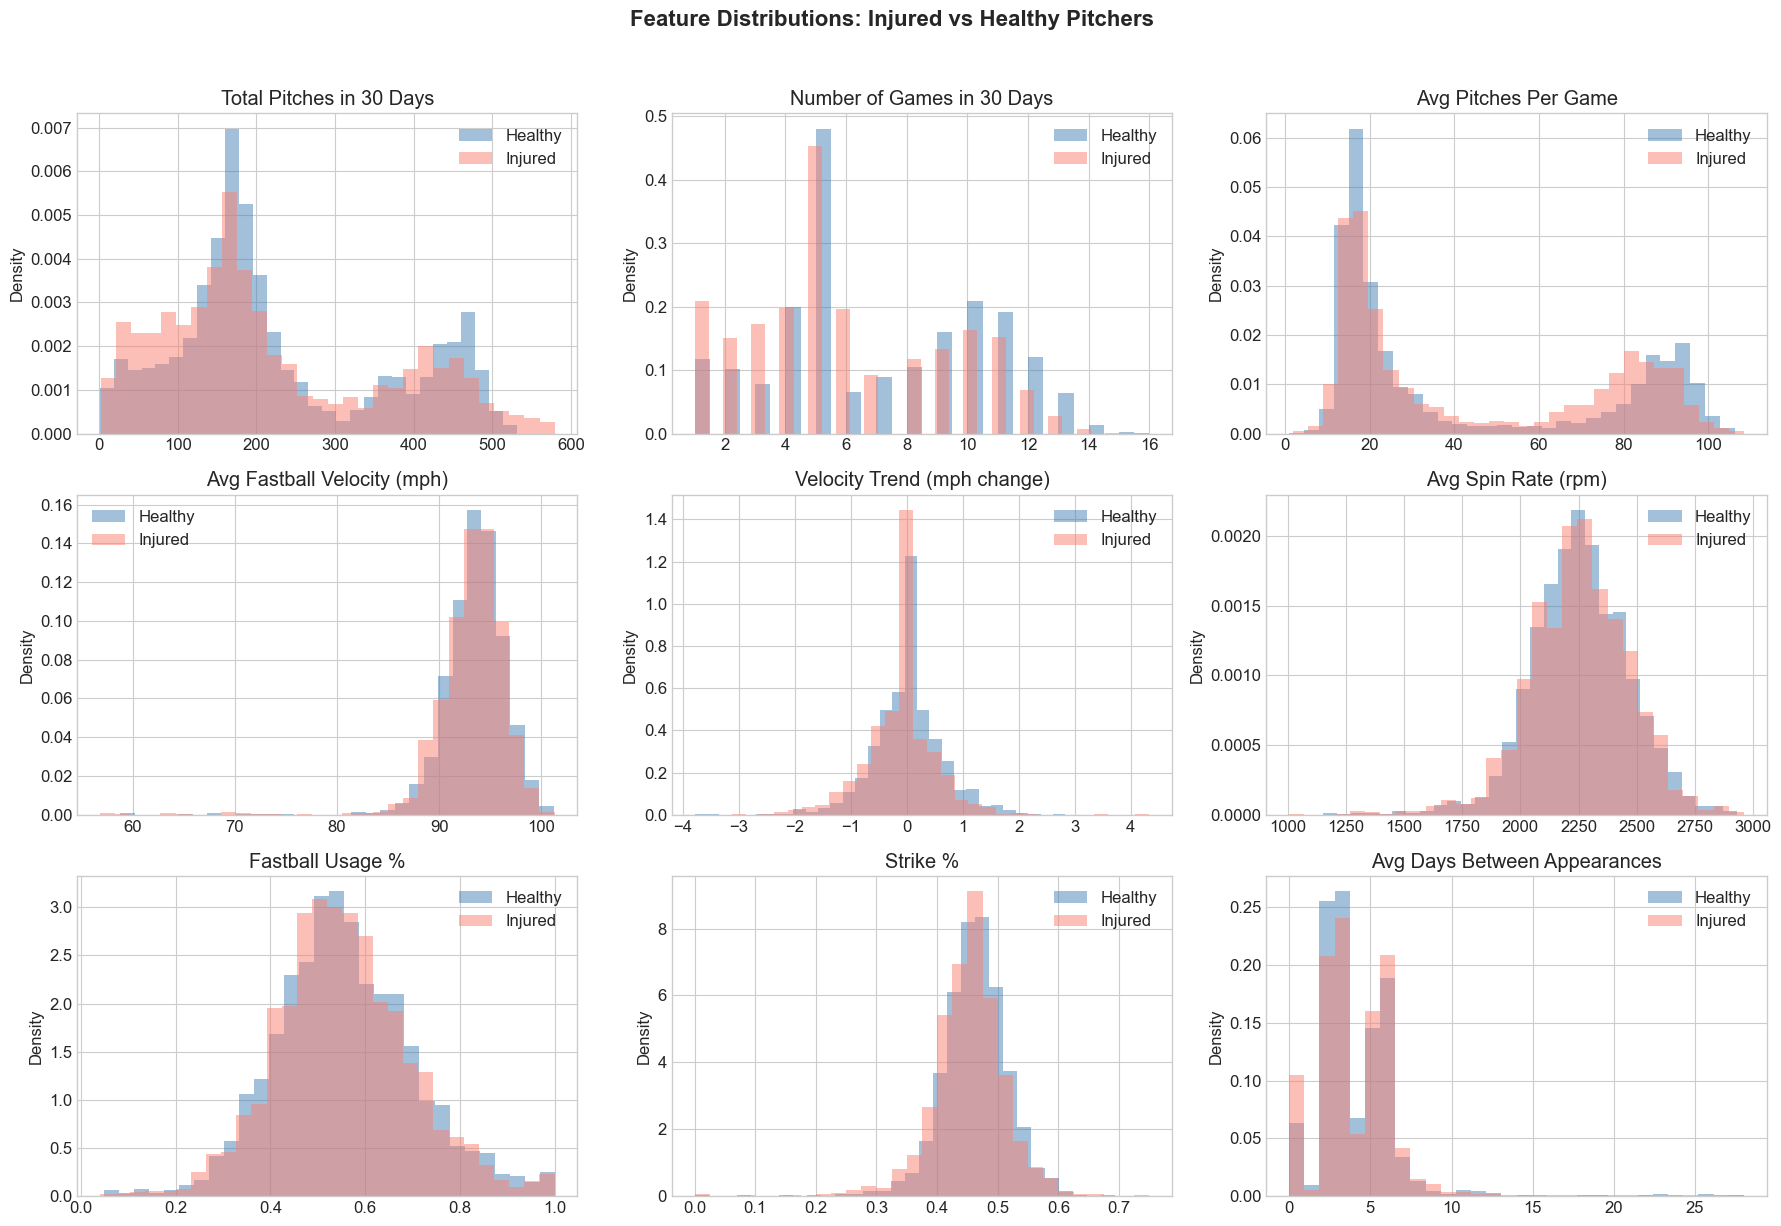

Distribution plot saved to data/raw/eda_distributions.png


In [51]:
injured_group = modeling_df[modeling_df["injured"] == 1]
healthy_group = modeling_df[modeling_df["injured"] == 0]

#Features to compare
features_to_plot = [
    ("total_pitches_30d", "Total Pitches in 30 Days"),
    ("num_games_30d", "Number of Games in 30 Days"),
    ("avg_pitches_per_game", "Avg Pitches Per Game"),
    ("avg_fb_velo_30d", "Avg Fastball Velocity (mph)"),
    ("velo_trend", "Velocity Trend (mph change)"),
    ("avg_spin_30d", "Avg Spin Rate (rpm)"),
    ("avg_fb_pct", "Fastball Usage %"),
    ("avg_strike_pct", "Strike %"),
    ("avg_days_rest", "Avg Days Between Appearances"),
]

#create a figure with subplots
num_features = len(features_to_plot)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))

#flatten the axes array to loop through it
axes_flat = axes.flatten()

for i in range(num_features):
    col_name = features_to_plot[i][0]
    col_label = features_to_plot[i][1]
    ax = axes_flat[i]
    
    #Plot histograms for both groups on the same axes
    ax.hist(healthy_group[col_name].dropna(), bins=30, alpha=0.5, 
            label="Healthy", color="steelblue", density=True)
    ax.hist(injured_group[col_name].dropna(), bins=30, alpha=0.5, 
            label="Injured", color="salmon", density=True)
    
    ax.set_title(col_label)
    ax.set_ylabel("Density")
    ax.legend()

#hide any extra subplot spaces
for j in range(num_features, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Feature Distributions: Injured vs Healthy Pitchers", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/raw/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Distribution plot saved to data/raw/eda_distributions.png")

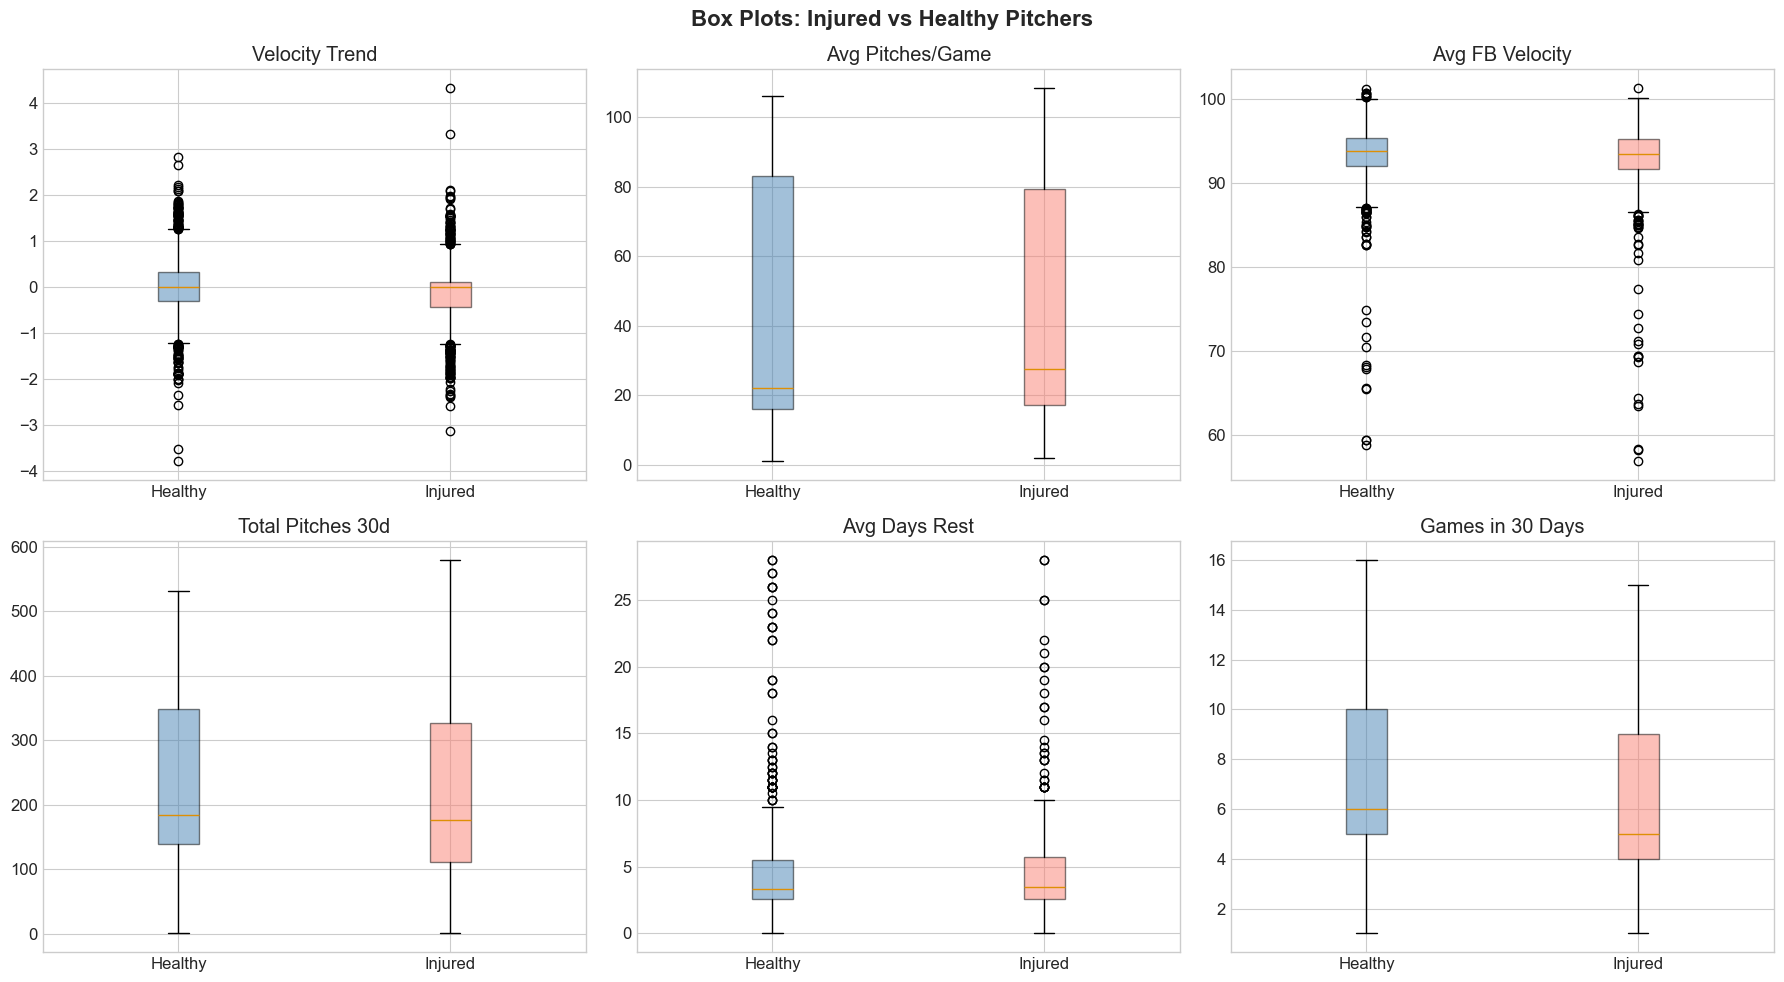

Box plot saved to data/raw/eda_boxplots.png


In [53]:
#Pick the most interstsing features
box_features = [
    ("velo_trend", "Velocity Trend"),
    ("avg_pitches_per_game", "Avg Pitches/Game"),
    ("avg_fb_velo_30d", "Avg FB Velocity"),
    ("total_pitches_30d", "Total Pitches 30d"),
    ("avg_days_rest", "Avg Days Rest"),
    ("num_games_30d", "Games in 30 Days"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i in range(len(box_features)):
    col_name = box_features[i][0]
    col_label = box_features[i][1]
    ax = axes_flat[i]

    #create data for the box plot
    data_to_plot = [
        healthy_group[col_name].dropna(),
        injured_group[col_name].dropna()
    ]

    box = ax.boxplot(data_to_plot, labels=["Healthy", "Injured"],
                     patch_artist=True)

    #Color the boxes
    box["boxes"][0].set_facecolor("steelblue")
    box["boxes"][0].set_alpha(0.5)
    box["boxes"][1].set_facecolor("salmon")
    box["boxes"][1].set_alpha(0.5)

    ax.set_title(col_label)

plt.suptitle("Box Plots: Injured vs Healthy Pitchers", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Box plot saved to data/raw/eda_boxplots.png")

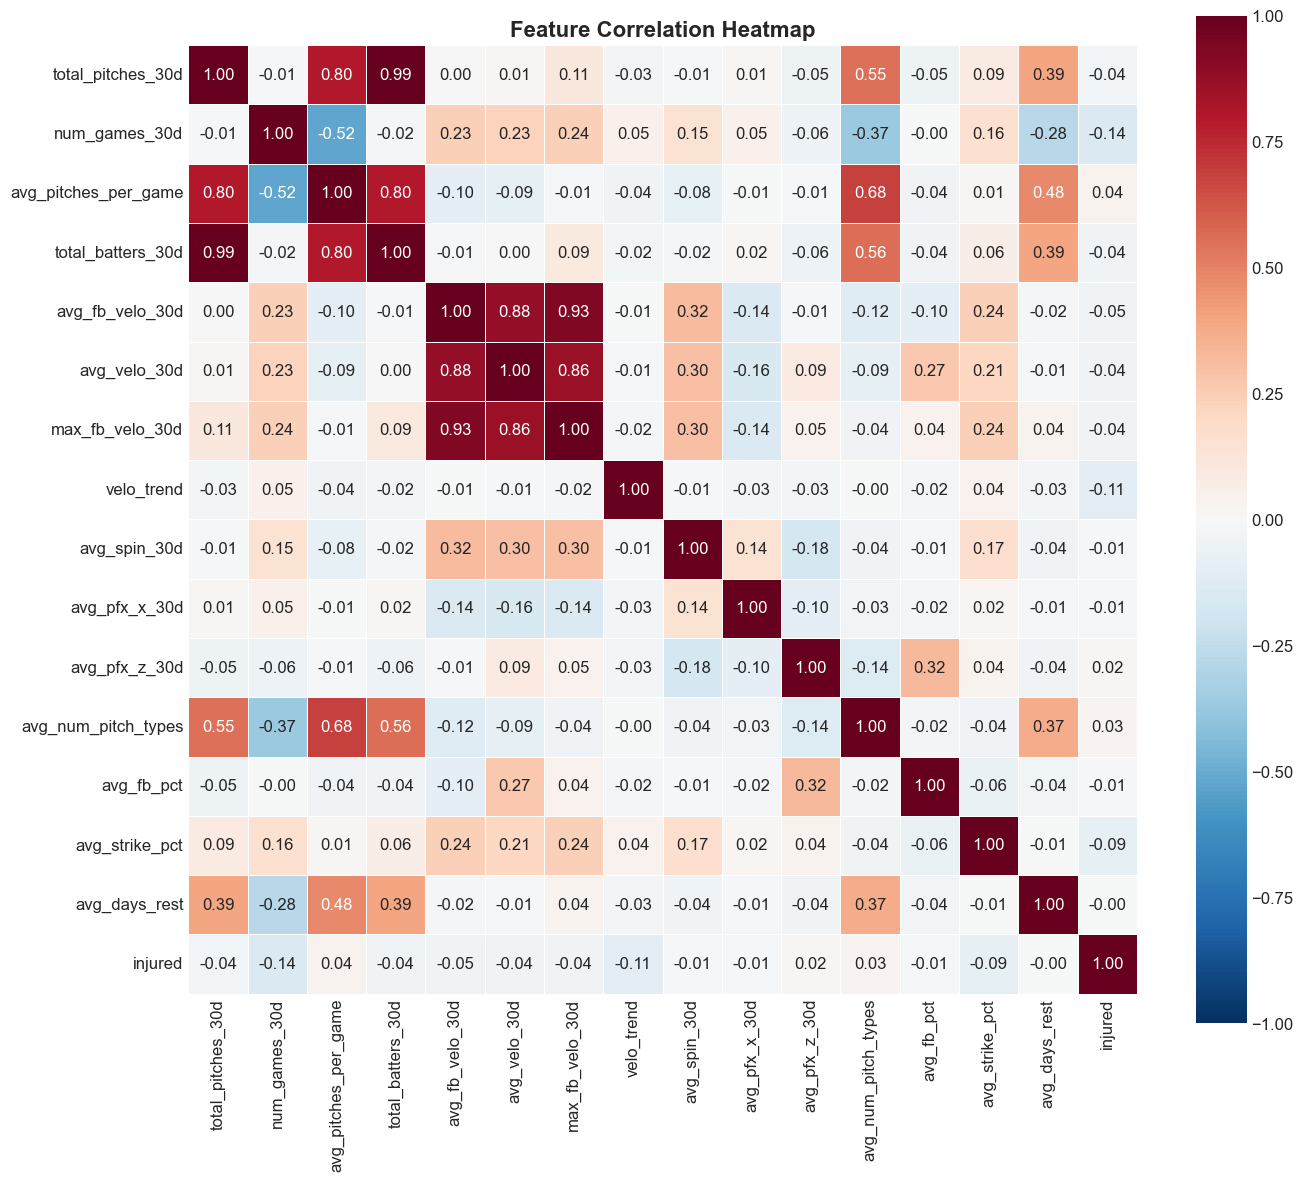

Correlations with 'injured' (sorted by absolute value):
--------------------------------------------------
  num_games_30d              -0.1431
  velo_trend                 -0.1059
  avg_strike_pct             -0.0882
  avg_fb_velo_30d            -0.0461
  max_fb_velo_30d            -0.0449
  total_batters_30d          -0.0432
  avg_velo_30d               -0.0405
  total_pitches_30d          -0.0386
  avg_pitches_per_game        0.0356
  avg_num_pitch_types         0.0251
  avg_pfx_z_30d               0.0232
  avg_fb_pct                 -0.0147
  avg_pfx_x_30d              -0.0121
  avg_spin_30d               -0.0088
  avg_days_rest              -0.0015


In [90]:
heatmap_cols = [
    "total_pitches_30d", "num_games_30d", "avg_pitches_per_game",
    "total_batters_30d", "avg_fb_velo_30d", "avg_velo_30d",
    "max_fb_velo_30d", "velo_trend", "avg_spin_30d",
    "avg_pfx_x_30d", "avg_pfx_z_30d", "avg_num_pitch_types",
    "avg_fb_pct", "avg_strike_pct", "avg_days_rest",
    "injured"
]

#Calculate the correlation matrix
corr_matrix = modeling_df[heatmap_cols].corr()

#create the heatmap
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f",
            cmap="RdBu_r",       #Red-blue color scheme
            center=0,
            square=True, 
            linewidths=0.5,      #add lines between cells
            ax=ax,
            vmin=-1, vmax=1)     #Set color scale range

ax.set_title("Feature Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

#print the correlations with the target variable (injured)
print("Correlations with 'injured' (sorted by absolute value):")
print("-" * 50)
injury_corr = corr_matrix["injured"].drop("injured")
#Sort by absolute value
injury_corr_sorted = injury_corr.reindex(injury_corr.abs().sort_values(ascending=False).index)
for feature in injury_corr_sorted.index:
    value = injury_corr_sorted[feature]
    print(f"  {feature:<25} {value:>8.4f}")

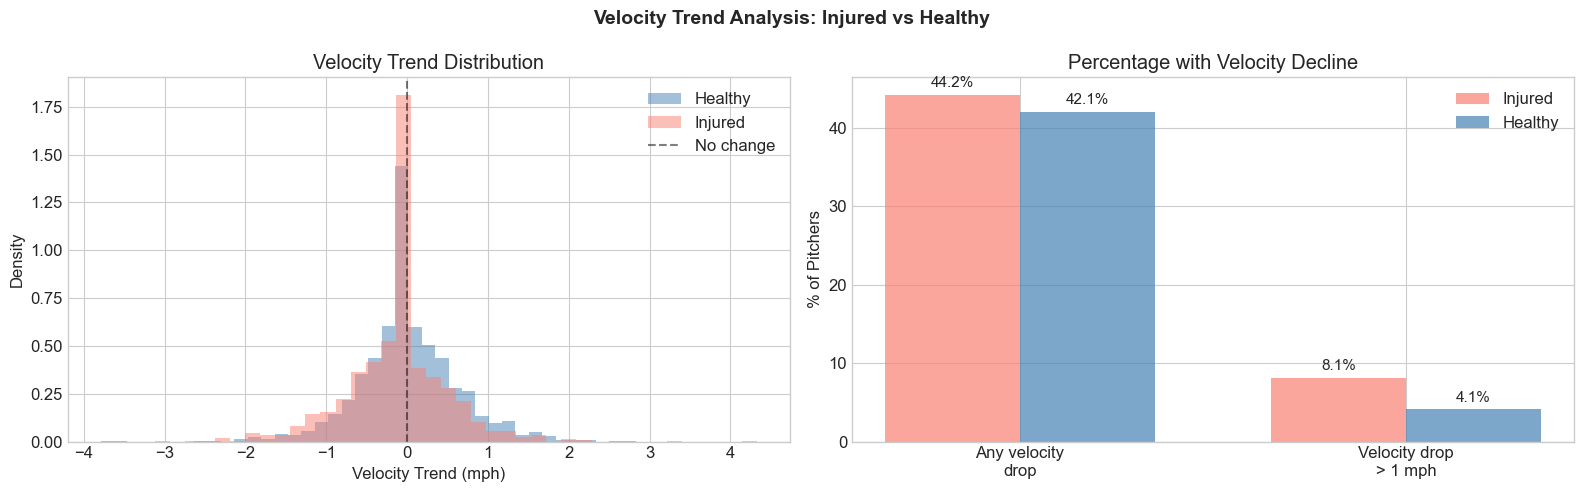

Injured pitchers with velocity decline: 44.2%
Healthy pitchers with velocity decline: 42.1%
Injured pitchers with >1 mph drop: 8.1%
Healthy pitchers with >1 mph drop: 4.1%


In [57]:
#velocity trend distribution zoomed in
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
#Overlapping histogram of velocity trend
ax1 = axes[0]
ax1.hist(healthy_group["velo_trend"].dropna(), bins=40, alpha=0.5,
         label="Healthy", color="steelblue", density=True)
ax1.hist(injured_group["velo_trend"].dropna(), bins=40, alpha=0.5,
         label="Injured", color="salmon", density=True)
ax1.axvline(x=0, color="black", linestyle="--", alpha=0.5, label="No change")
ax1.set_xlabel("Velocity Trend (mph)")
ax1.set_ylabel("Density")
ax1.set_title("Velocity Trend Distribution")
ax1.legend()
 
#what % of each group has a negative velocity trend?
ax2 = axes[1]

injured_neg_pct = (injured_group["velo_trend"] < 0).mean() * 100
healthy_neg_pct = (healthy_group["velo_trend"] < 0).mean() * 100
injured_big_neg = (injured_group["velo_trend"] < -1).mean() * 100
healthy_big_neg = (healthy_group["velo_trend"] < -1).mean() * 100

categories = ["Any velocity\ndrop", "Velocity drop\n> 1 mph"]
injured_values = [injured_neg_pct, injured_big_neg]
healthy_values = [healthy_neg_pct, healthy_big_neg]

x_pos = [0, 1]
width = 0.35
ax2.bar([p - width/2 for p in x_pos], injured_values, width, 
        label="Injured", color="salmon", alpha=0.7)
ax2.bar([p + width/2 for p in x_pos], healthy_values, width, 
        label="Healthy", color="steelblue", alpha=0.7)

#add percentage labels on bars
for j in range(len(x_pos)):
    ax2.text(x_pos[j] - width/2, injured_values[j] + 1, 
             f"{injured_values[j]:.1f}%", ha="center", fontsize=11)
    ax2.text(x_pos[j] + width/2, healthy_values[j] + 1, 
             f"{healthy_values[j]:.1f}%", ha="center", fontsize=11)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories)
ax2.set_ylabel("% of Pitchers")
ax2.set_title("Percentage with Velocity Decline")
ax2.legend()

plt.suptitle("Velocity Trend Analysis: Injured vs Healthy", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/eda_velocity_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Injured pitchers with velocity decline: {injured_neg_pct:.1f}%")
print(f"Healthy pitchers with velocity decline: {healthy_neg_pct:.1f}%")
print(f"Injured pitchers with >1 mph drop: {injured_big_neg:.1f}%")
print(f"Healthy pitchers with >1 mph drop: {healthy_big_neg:.1f}%")

Most Common Pitcher Injuries:
--------------------------------------------------
  Right shoulder inflammation                 84  (6.1%)
  Right elbow inflammation                    82  (5.9%)
  Right shoulder strain                       39  (2.8%)
  Right shoulder impingement                  34  (2.5%)
  Left oblique strain                         34  (2.5%)
  Right forearm strain                        31  (2.2%)
  Left elbow inflammation                     28  (2.0%)
  Left hamstring strain                       27  (1.9%)
  Right lat strain                            21  (1.5%)
  Right oblique strain                        21  (1.5%)
  Right groin strain                          20  (1.4%)
  Left shoulder inflammation                  20  (1.4%)
  Right elbow sprain                          18  (1.3%)
  Right hamstring strain                      16  (1.2%)
  Right elbow strain                          15  (1.1%)


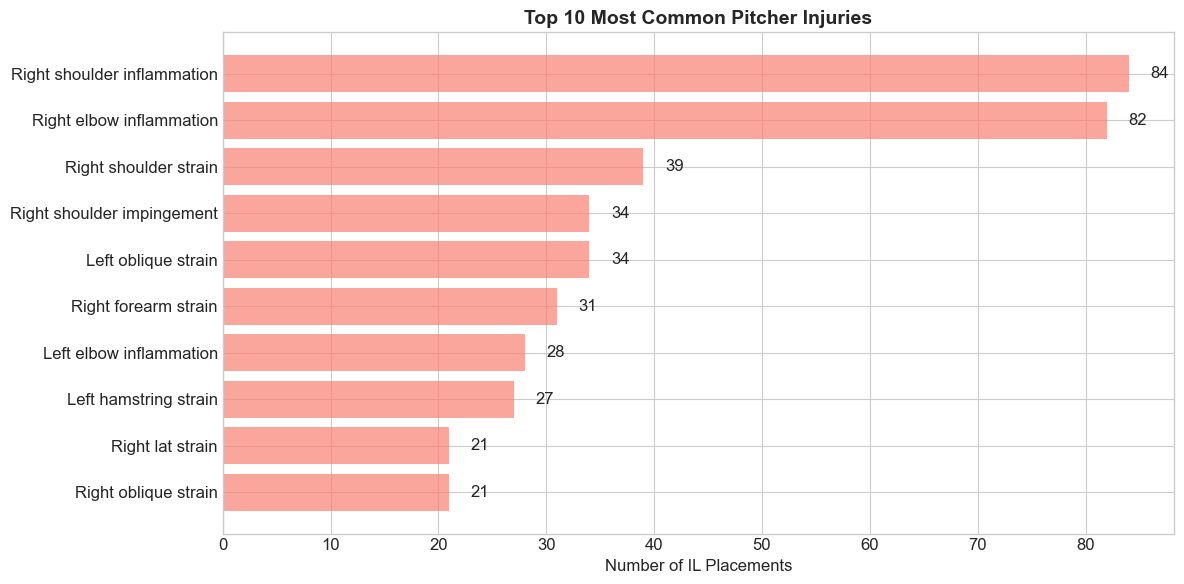

In [59]:
#get the injury column from the injured snapshots
injured_with_injury = injured_group[injured_group["injury"].notna()]
injured_with_injury = injured_with_injury[injured_with_injury["injury"] != "none"]
injured_with_injury = injured_with_injury[injured_with_injury["injury"] != ""]

#Count each injury type
injury_counts = injured_with_injury["injury"].value_counts()

# Show top 15 injuries
print("Most Common Pitcher Injuries:")
print("-" * 50)
for i in range(min(15, len(injury_counts))):
    injury_name = injury_counts.index[i]
    count = injury_counts.values[i]
    pct = count / len(injured_with_injury) * 100
    print(f"  {injury_name:<40} {count:>5}  ({pct:.1f}%)")

#plot the top 10 injuries
top_n = 10
top_injuries = injury_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(top_n), top_injuries.values, color="salmon", alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_injuries.index)
ax.invert_yaxis()  # Highest count at the top
ax.set_xlabel("Number of IL Placements")
ax.set_title("Top 10 Most Common Pitcher Injuries", fontsize=14, fontweight="bold")

#Add labels on bars
for i in range(len(bars)):
    ax.text(bars[i].get_width() + 2, bars[i].get_y() + bars[i].get_height()/2,
            str(top_injuries.values[i]), va="center")

plt.tight_layout()
plt.savefig("data/raw/eda_injury_types.png", dpi=150, bbox_inches="tight")
plt.show()

In [65]:
print("Statistical Significance Tests (Independent t-test)")
print("=" * 70)
print(f"{'Feature':<25} {'Injured Mean':>13} {'Healthy Mean':>13} {'t-stat':>8} {'p-value':>10} {'Significant?':>13}")
print("-" * 82)

test_features = [
    "total_pitches_30d", "num_games_30d", "avg_pitches_per_game",
    "avg_fb_velo_30d", "velo_trend", "avg_spin_30d",
    "avg_fb_pct", "avg_strike_pct", "avg_days_rest"
]

for col in test_features:
    injured_vals = injured_group[col].dropna()
    healthy_vals = healthy_group[col].dropna()

    #Run a two-sample t-test
    t_stat, p_value = stats.ttest_ind(injured_vals, healthy_vals)

    injured_mean = injured_vals.mean()
    healthy_mean = healthy_vals.mean()

    #mark as significant if p < 0.05
    if p_value < 0.001:
        sig = "*** (p<0.001)"
    elif p_value < 0.01:
        sig = "** (p<0.01)"
    elif p_value < 0.05:
        sig = "* (p<0.05)"
    else:
        sig = "No"

    print(f"{col:<25} {injured_mean:>13.2f} {healthy_mean:>13.2f} {t_stat:>8.2f} {p_value:>10.4f} {sig:>13}")

Statistical Significance Tests (Independent t-test)
Feature                    Injured Mean  Healthy Mean   t-stat    p-value  Significant?
----------------------------------------------------------------------------------
total_pitches_30d                217.33        228.17    -2.36     0.0185    * (p<0.05)
num_games_30d                      5.91          6.89    -8.83     0.0000 *** (p<0.001)
avg_pitches_per_game              44.75         42.44     2.18     0.0295    * (p<0.05)
avg_fb_velo_30d                   93.14         93.47    -2.82     0.0048   ** (p<0.01)
velo_trend                        -0.11          0.02    -6.51     0.0000 *** (p<0.001)
avg_spin_30d                    2252.05       2255.91    -0.54     0.5898            No
avg_fb_pct                         0.55          0.56    -0.90     0.3696            No
avg_strike_pct                     0.45          0.46    -5.41     0.0000 *** (p<0.001)
avg_days_rest                      4.13          4.14    -0.09     0.9280

So far this is looking good; num_games_30d, velo_trend, and avg_strike_pct are highly significant features with p<0.001. Additionally, avg_fb_velo_30d and avg_pitches_per_game are also significant with p<0.05. With these results, I think I'm ready to start modeling using logistic regression.

In [68]:
#pick the columns the model will use to make predictions
feature_cols = [
    "total_pitches_30d",
    "num_games_30d",
    "avg_pitches_per_game",
    "total_batters_30d",
    "avg_fb_velo_30d",
    "avg_velo_30d",
    "max_fb_velo_30d",
    "velo_trend",
    "avg_spin_30d",
    "avg_pfx_x_30d",
    "avg_pfx_z_30d",
    "avg_num_pitch_types",
    "avg_fb_pct",
    "avg_strike_pct",
    "avg_days_rest",
]

X = modeling_df[feature_cols] #features
y = modeling_df["injured"] #target

print(f"Features (X): {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} values")
print(f"  Class distribution: {y.value_counts().to_dict()}")

Features (X): 3730 rows x 15 columns
Target (y): 3730 values
  Class distribution: {0: 2102, 1: 1628}


In [70]:
#Split the data into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,     #for reproducibility
    stratify=y           #keep class balance in both sets
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"  Injured: {y_train.sum()}")
print(f"  Healthy: {len(y_train) - y_train.sum()}")
print(f"\nTest set: {X_test.shape[0]} rows")
print(f"  Injured: {y_test.sum()}")
print(f"  Healthy: {len(y_test) - y_test.sum()}")

Training set: 2984 rows
  Injured: 1302
  Healthy: 1682

Test set: 746 rows
  Injured: 326
  Healthy: 420


In [72]:
scaler = StandardScaler()

#Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

#transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Before scaling first row sample: {X_train.iloc[0].values[:5]}")
print(f"After scaling first row sample: {X_train_scaled[0][:5]}")

Features scaled successfully.
Before scaling first row sample: [119.    2.   59.5  31.   88.8]
After scaling first row sample: [-0.74093711 -1.32171143  0.53024252 -0.72078374 -1.33959004]


In [74]:
log_reg = LogisticRegression(
    random_state=42,     # For reproducibility
    max_iter=1000        # Give it enough iterations to converge
)

#train the model on the training data
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained")

Logistic Regression model trained


In [76]:
#Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)

#get probability predictions needed for AUC-ROC
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

#classification report and AUC-ROC score
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Healthy", "Injured"]))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_score:.4f}")

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.60      0.78      0.68       420
     Injured       0.54      0.33      0.41       326

    accuracy                           0.58       746
   macro avg       0.57      0.55      0.54       746
weighted avg       0.57      0.58      0.56       746

AUC-ROC Score: 0.6047


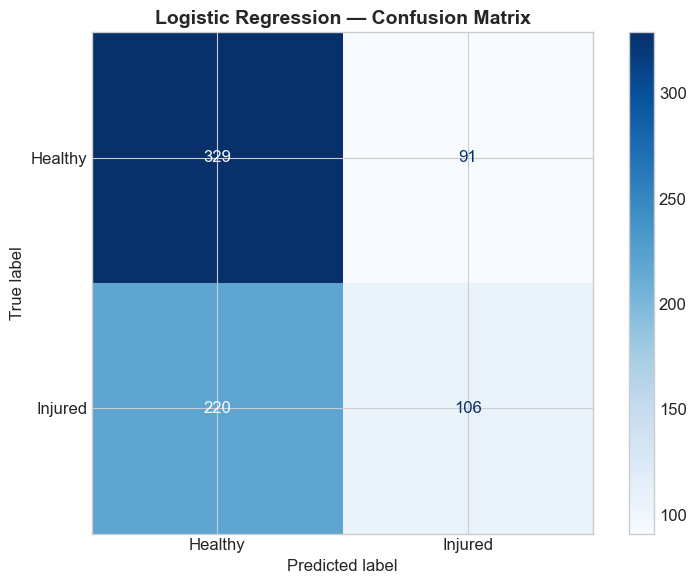


Confusion Matrix Breakdown:
 True Negatives (correctly predicted healthy):  329
 False Positives (healthy but predicted injured): 91
 False Negatives (injured but predicted healthy): 220
 True Positives (correctly predicted injured):  106


In [78]:
#confusion Matrix

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Healthy", "Injured"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Logistic Regression — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/model_logreg_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

#Explain the confusion matrix
tn = ((y_test == 0) & (y_pred == 0)).sum()
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()
tp = ((y_test == 1) & (y_pred == 1)).sum()

print(f"\nConfusion Matrix Breakdown:")
print(f" True Negatives (correctly predicted healthy):  {tn}")
print(f" False Positives (healthy but predicted injured): {fp}")
print(f" False Negatives (injured but predicted healthy): {fn}")
print(f" True Positives (correctly predicted injured):  {tp}")

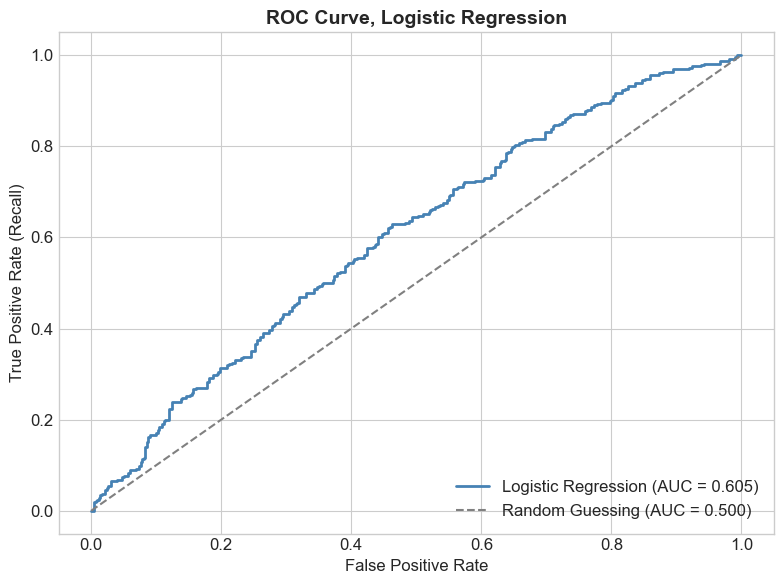

In [80]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, 
        label=f"Logistic Regression (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guessing (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve, Logistic Regression", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("data/raw/model_logreg_roc.png", dpi=150, bbox_inches="tight")
plt.show()

Logistic Regression Coefficients (Feature Importance):
------------------------------------------------------------
  total_pitches_30d           0.6863  → Injured
  total_batters_30d          -0.6483  → Healthy
  num_games_30d              -0.3299  → Healthy
  avg_fb_velo_30d            -0.2304  → Healthy
  velo_trend                 -0.2247  → Healthy
  avg_velo_30d                0.1857  → Injured
  avg_strike_pct             -0.1729  → Healthy
  avg_fb_pct                 -0.1696  → Healthy
  avg_pitches_per_game       -0.1311  → Healthy
  avg_days_rest              -0.0620  → Healthy
  avg_pfx_z_30d               0.0552  → Injured
  avg_spin_30d                0.0388  → Injured
  max_fb_velo_30d             0.0332  → Injured
  avg_num_pitch_types         0.0279  → Injured
  avg_pfx_x_30d              -0.0100  → Healthy


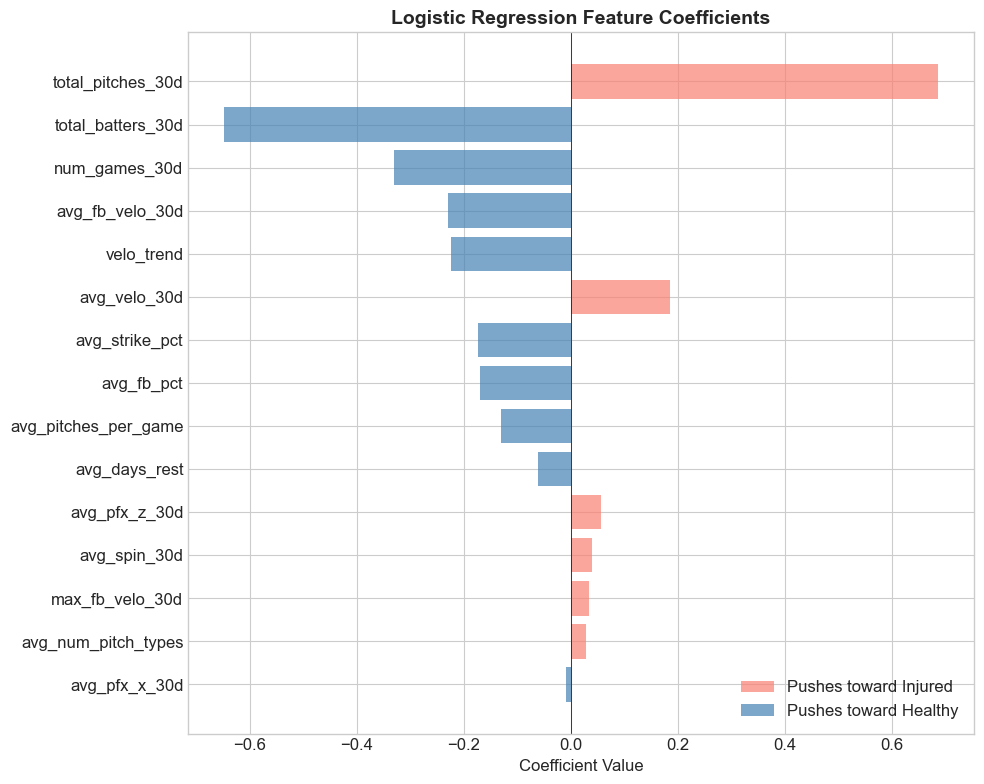

In [82]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_reg.coef_[0]
})

#sort by absolute value
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Logistic Regression Coefficients (Feature Importance):")
print("-" * 60)
for i in range(len(coef_df)):
    row = coef_df.iloc[i]
    direction = "→ Injured" if row["coefficient"] > 0 else "→ Healthy"
    print(f"  {row['feature']:<25} {row['coefficient']:>8.4f}  {direction}")

#plot the coefficients
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["salmon" if c > 0 else "steelblue" for c in coef_df["coefficient"]]
ax.barh(range(len(coef_df)), coef_df["coefficient"], color=colors, alpha=0.7)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df["feature"])
ax.invert_yaxis()
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression Feature Coefficients", fontsize=14, fontweight="bold")

#legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="salmon", alpha=0.7, label="Pushes toward Injured"),
    Patch(facecolor="steelblue", alpha=0.7, label="Pushes toward Healthy")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("data/raw/model_logreg_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [84]:
#Run 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
#scale the features for each fold separately
cv_scores = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    scaler.fit_transform(X),  # Scale all data
    y,
    cv=cv,
    scoring="roc_auc" 
)

print("5-Fold Cross-Validation Results (AUC-ROC):")
print("-" * 40)
for i in range(len(cv_scores)):
    print(f"  Fold {i + 1}: {cv_scores[i]:.4f}")

print(f"\n  Mean AUC: {cv_scores.mean():.4f}")
print(f"  Std Dev:  {cv_scores.std():.4f}")

5-Fold Cross-Validation Results (AUC-ROC):
----------------------------------------
  Fold 1: 0.6048
  Fold 2: 0.6130
  Fold 3: 0.6659
  Fold 4: 0.6063
  Fold 5: 0.5682

  Mean AUC: 0.6116
  Std Dev:  0.0313


In [86]:
#Now the Random Forest Model for capturing any non-linear patterns

rf_model = RandomForestClassifier(
    n_estimators=200,     # Number of trees in the forest
    max_depth=10,         # How deep each tree can grow (prevents overfitting)
    min_samples_leaf=10,  # Each leaf must have at least 10 samples
    random_state=42,      # For reproducibility
    class_weight="balanced"  # Adjusts for any remaining class imbalance
)

#train on the unscaled training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained!")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")

Random Forest model trained!
  Number of trees: 200
  Max depth: 10


In [88]:
#make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
 
#classification Report
print("Random Forest, Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Healthy", "Injured"]))
 
#AUC-ROC
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"AUC-ROC Score: {auc_rf:.4f}")

Random Forest, Classification Report:
              precision    recall  f1-score   support

     Healthy       0.65      0.67      0.66       420
     Injured       0.56      0.54      0.55       326

    accuracy                           0.61       746
   macro avg       0.61      0.60      0.61       746
weighted avg       0.61      0.61      0.61       746

AUC-ROC Score: 0.6541


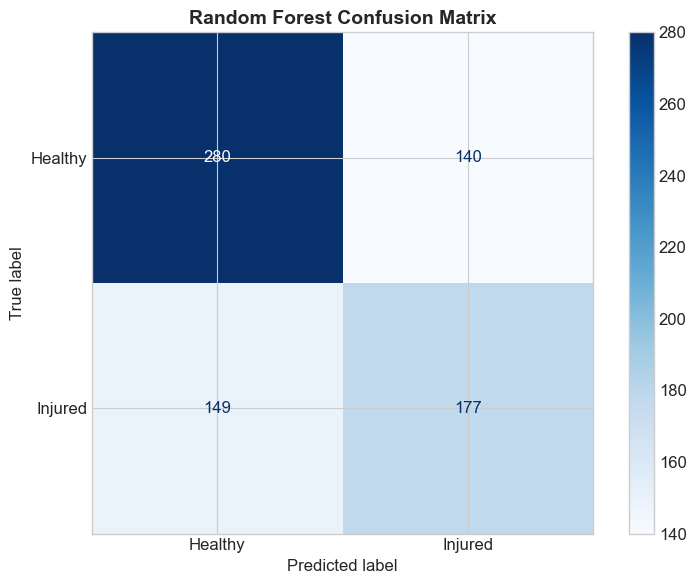

In [94]:
#confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Healthy", "Injured"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Random Forest Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/model_rf_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

Random Forest Feature Importance:
--------------------------------------------------
  avg_pitches_per_game      0.1158  ███████████
  velo_trend                0.1063  ██████████
  total_pitches_30d         0.0889  ████████
  avg_strike_pct            0.0790  ███████
  total_batters_30d         0.0756  ███████
  num_games_30d             0.0701  ███████
  avg_fb_pct                0.0621  ██████
  avg_spin_30d              0.0619  ██████
  avg_pfx_z_30d             0.0535  █████
  avg_pfx_x_30d             0.0517  █████
  avg_velo_30d              0.0504  █████
  avg_days_rest             0.0491  ████
  avg_fb_velo_30d           0.0474  ████
  max_fb_velo_30d           0.0461  ████
  avg_num_pitch_types       0.0422  ████


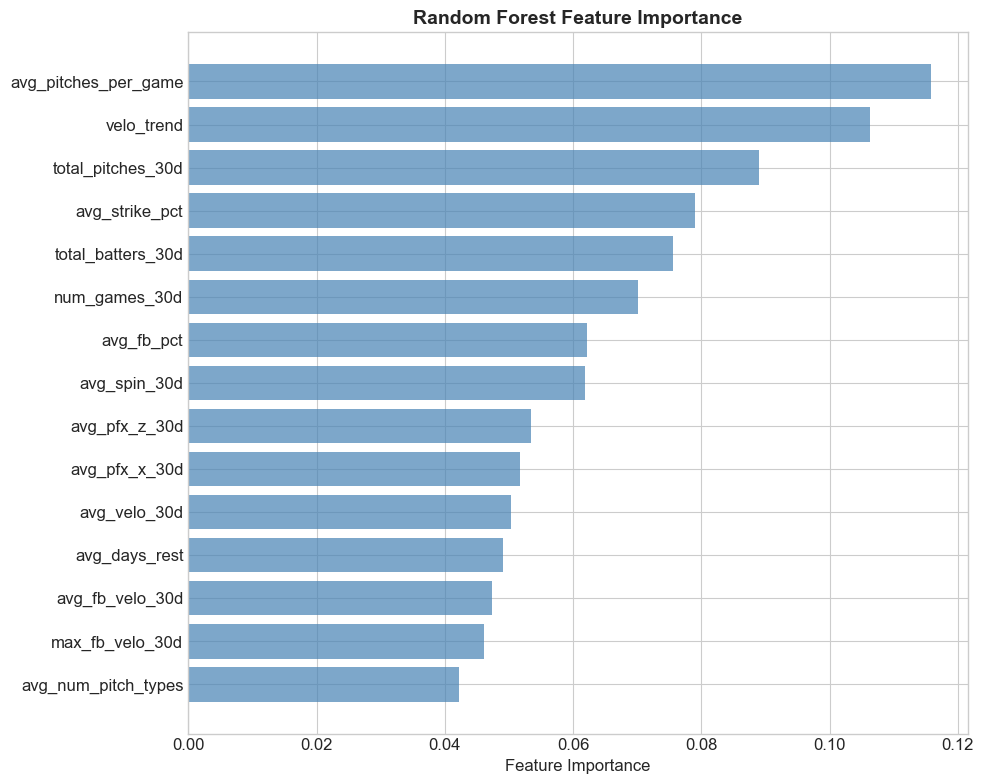

In [96]:
#Get feature importances
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

#sort
importance_df = importance_df.sort_values("importance", ascending=False)

print("Random Forest Feature Importance:")
print("-" * 50)
for i in range(len(importance_df)):
    row = importance_df.iloc[i]
    bar = "█" * int(row["importance"] * 100)
    print(f"  {row['feature']:<25} {row['importance']:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(importance_df)), importance_df["importance"], 
        color="steelblue", alpha=0.7)
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df["feature"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/model_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [98]:
#Cross-validation for Random Forest
cv_scores_rf = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        random_state=42, class_weight="balanced"
    ),
    X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("Random Forest 5-Fold Cross-Validation (AUC-ROC):")
print("-" * 40)
for i in range(len(cv_scores_rf)):
    print(f"  Fold {i + 1}: {cv_scores_rf[i]:.4f}")

print(f"\n  Mean AUC: {cv_scores_rf.mean():.4f}")
print(f"  Std Dev:  {cv_scores_rf.std():.4f}")

Random Forest 5-Fold Cross-Validation (AUC-ROC):
----------------------------------------
  Fold 1: 0.6210
  Fold 2: 0.6783
  Fold 3: 0.6650
  Fold 4: 0.6579
  Fold 5: 0.6356

  Mean AUC: 0.6516
  Std Dev:  0.0206


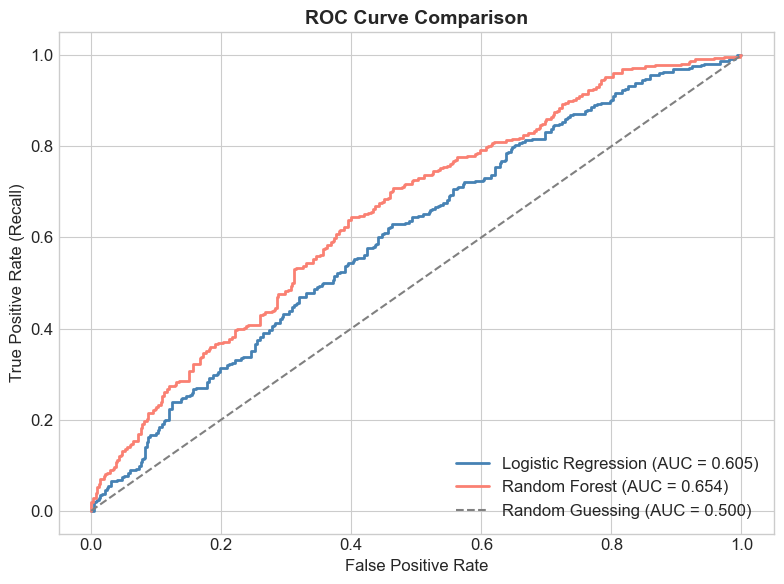


Model Comparison Summary:
Metric                            Log. Reg. Rand. Forest
-------------------------------------------------------
Test AUC-ROC                         0.6047       0.6541
CV Mean AUC-ROC                      0.6116       0.6516
CV Std Dev                           0.0313       0.0206


In [102]:
#ROC Curves for both models on same plot
fig, ax = plt.subplots(figsize=(8, 6))

#Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr_lr, tpr_lr, color="steelblue", linewidth=2,
        label=f"Logistic Regression (AUC = {auc_score:.3f})")

#Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
ax.plot(fpr_rf, tpr_rf, color="salmon", linewidth=2,
        label=f"Random Forest (AUC = {auc_rf:.3f})")

#Random baseline
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", 
        label="Random Guessing (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("data/raw/model_comparison_roc.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print("\nModel Comparison Summary:")
print("=" * 55)
print(f"{'Metric':<30} {'Log. Reg.':>12} {'Rand. Forest':>12}")
print("-" * 55)
print(f"{'Test AUC-ROC':<30} {auc_score:>12.4f} {auc_rf:>12.4f}")
print(f"{'CV Mean AUC-ROC':<30} {cv_scores.mean():>12.4f} {cv_scores_rf.mean():>12.4f}")
print(f"{'CV Std Dev':<30} {cv_scores.std():>12.4f} {cv_scores_rf.std():>12.4f}")

Both models perform better than random guessing, but neither is particularly strong by itself. An AUC of 0.65 means that if I picked one injured pitcher and one healthy pitcher at random, the model will correctly identify which is which 65% of the time.  
When comparing the two models, Random Forest seems to outperform Logistic Regression by only about 4 percentage points (0.65 vs 0.61), which lower variance across folds, which means its also more stable. This could suggest that there are some non-linear patterns tor feature interactions that the linear model isn't capturing.  
One thing I did notie earlier is that the distribution plot showed a bimodal pattern in pitches per game. I know that starting pitchers and relief pitchers have very different workload patterns and risks, so I'm wondering if a flag like 'is this a starting pitcher' can improve the model performance. I'm going to add this feature and rerun the Random Forest model to see if it helps.

In [106]:
#Calculate median pitches per game for all seasons
pitcher_medians = game_summary.groupby("pitcher")["total_pitches"].median()
pitcher_medians.name = "median_pitches_per_game"
pitcher_medians = pitcher_medians.reset_index()

#Identify starting pitchers by seeing if they pitched in inning 1 of a game
starter_records = []

for file_name in statcast_files:
    file_path = os.path.join(data_folder, file_name)
    if not os.path.exists(file_path):
        continue
        
    #only load the columns we need
    cols_needed = ["pitcher", "game_date", "game_pk", "inning", "inning_topbot"]
    df = pd.read_csv(file_path, usecols=cols_needed, low_memory=False)
    df["game_date"] = pd.to_datetime(df["game_date"])

    #Find pitchers who appeared in inning 1
    inning_1 = df[df["inning"] == 1]

    #Get unique (pitcher, game_date) pairs for inning 1
    starters_in_file = inning_1[["pitcher", "game_date"]].drop_duplicates()
    starters_in_file["was_starter"] = 1

    #get ALL unique (pitcher, game_date) pairs in the file
    all_appearances = df[["pitcher", "game_date"]].drop_duplicates()

    #merge to flag starters
    appearances = all_appearances.merge(
        starters_in_file,
        on=["pitcher", "game_date"],
        how="left"
    )

    #fill NaN (not a starter) with 0
    appearances["was_starter"] = appearances["was_starter"].fillna(0)
    appearances["was_starter"] = appearances["was_starter"].astype(int)

    starter_records.append(appearances)

    starter_count = appearances["was_starter"].sum()
    relief_count = len(appearances) - starter_count
    print(f"  {file_name}: {starter_count} starts, {relief_count} relief appearances")

#Combine all files
all_appearances = pd.concat(starter_records, ignore_index=True)

print(f"\nTotal appearances: {len(all_appearances)}")
print(f"  Starts: {all_appearances['was_starter'].sum()}")
print(f"  Relief: {len(all_appearances) - all_appearances['was_starter'].sum()}")

  statcast_2021_buffer.csv: 980 starts, 3669 relief appearances
  statcast_2022.csv: 5154 starts, 17041 relief appearances
  statcast_2023.csv: 4979 starts, 16054 relief appearances
  statcast_2024.csv: 5157 starts, 16943 relief appearances
  statcast_2025.csv: 5138 starts, 17030 relief appearances

Total appearances: 92145
  Starts: 21408
  Relief: 70737


In [108]:
#For each pitcher, calculate their start percentage across all games
pitcher_start_pct = all_appearances.groupby("pitcher")["was_starter"].mean()
pitcher_start_pct.name = "start_pct"
pitcher_start_pct = pitcher_start_pct.reset_index()

#if a pitcher starts >= 50% of their games, they're a SP
role_list = []
for i in range(len(pitcher_start_pct)):
    if pitcher_start_pct.iloc[i]["start_pct"] >= 0.5:
        role_list.append("SP")
    else:
        role_list.append("RP")

pitcher_start_pct["role"] = role_list

#summary
sp_count = role_list.count("SP")
rp_count = role_list.count("RP")
print(f"Pitcher role classification (based on actual starts):")
print(f" Starting Pitchers (SP): {sp_count}")
print(f" Relief Pitchers (RP):   {rp_count}")

Pitcher role classification (based on actual starts):
 Starting Pitchers (SP): 393
 Relief Pitchers (RP):   1606


In [110]:
#Load the modeling dataset
modeling_df = pd.read_csv("data/raw/modeling_dataset.csv", parse_dates=["il_date"])

# Merge the role classification
modeling_df = modeling_df.merge(
    pitcher_start_pct[["pitcher", "start_pct", "role"]],
    on="pitcher",
    how="left"
)

#handle any missing values
missing_role = modeling_df["role"].isna().sum()
if missing_role > 0:
    print(f"Note: {missing_role} rows had no role data — defaulting to RP")
    modeling_df["role"] = modeling_df["role"].fillna("RP")
    modeling_df["start_pct"] = modeling_df["start_pct"].fillna(0)

#create a numeric version for modeling: SP = 1, RP = 0
modeling_df["is_starter"] = 0
for i in range(len(modeling_df)):
    if modeling_df.iloc[i]["role"] == "SP":
        modeling_df.at[modeling_df.index[i], "is_starter"] = 1

#check distribution and injury rates by role
print(f"\nRole distribution in modeling dataset:")
print(f"  SP: {modeling_df['is_starter'].sum()}")
print(f"  RP: {len(modeling_df) - modeling_df['is_starter'].sum()}")

print(f"\nInjury rate by role:")
for role_val in [0, 1]:
    role_name = "SP" if role_val == 1 else "RP"
    role_data = modeling_df[modeling_df["is_starter"] == role_val]
    injury_rate = role_data["injured"].mean()
    total = len(role_data)
    injured = role_data["injured"].sum()
    print(f"  {role_name}: {injury_rate:.1%} injured ({injured} of {total})")


Role distribution in modeling dataset:
  SP: 1227
  RP: 2503

Injury rate by role:
  RP: 41.5% injured (1038 of 2503)
  SP: 48.1% injured (590 of 1227)


In [112]:
#Updated feature list
feature_cols_v2 = [
    "total_pitches_30d",
    "num_games_30d",
    "avg_pitches_per_game",
    "total_batters_30d",
    "avg_fb_velo_30d",
    "avg_velo_30d",
    "max_fb_velo_30d",
    "velo_trend",
    "avg_spin_30d",
    "avg_pfx_x_30d",
    "avg_pfx_z_30d",
    "avg_num_pitch_types",
    "avg_fb_pct",
    "avg_strike_pct",
    "avg_days_rest",
    "is_starter", 
]

#prepare data
X_v2 = modeling_df[feature_cols_v2]
y_v2 = modeling_df["injured"]

#Drop any rows with missing values
missing_mask = X_v2.isna().any(axis=1)
X_v2 = X_v2[~missing_mask]
y_v2 = y_v2[~missing_mask]

print(f"Modeling data: {len(X_v2)} rows, {len(feature_cols_v2)} features")

#split into train/test
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

print(f"Train: {len(X_train_v2)} rows")
print(f"Test:  {len(X_test_v2)} rows")

#train the updated Random Forest
rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

rf_v2.fit(X_train_v2, y_train_v2)
print("\nRandom Forest v2 trained (with starter/reliever feature)")

Modeling data: 3730 rows, 16 features
Train: 2984 rows
Test:  746 rows

Random Forest v2 trained (with starter/reliever feature)


In [114]:
# Evaluate
y_pred_v2 = rf_v2.predict(X_test_v2)
y_pred_proba_v2 = rf_v2.predict_proba(X_test_v2)[:, 1]

print("\nRandom Forest v2 Classification Report:")
print("=" * 60)
print(classification_report(y_test_v2, y_pred_v2, target_names=["Healthy", "Injured"]))

auc_v2 = roc_auc_score(y_test_v2, y_pred_proba_v2)
print(f"AUC-ROC Score: {auc_v2:.4f}")

#Cross-validation
cv_scores_v2 = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        random_state=42, class_weight="balanced"
    ),
    X_v2, y_v2,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print(f"5-Fold CV Mean AUC: {cv_scores_v2.mean():.4f} (±{cv_scores_v2.std():.4f})")


Random Forest v2 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.65      0.67      0.66       420
     Injured       0.55      0.53      0.54       326

    accuracy                           0.61       746
   macro avg       0.60      0.60      0.60       746
weighted avg       0.61      0.61      0.61       746

AUC-ROC Score: 0.6582
5-Fold CV Mean AUC: 0.6578 (±0.0232)


Random Forest v2 Feature Importance:
-------------------------------------------------------
  avg_pitches_per_game      0.1131  ███████████
  velo_trend                0.1127  ███████████
  total_pitches_30d         0.0830  ████████
  avg_strike_pct            0.0808  ████████
  total_batters_30d         0.0742  ███████
  num_games_30d             0.0642  ██████
  avg_fb_pct                0.0624  ██████
  avg_spin_30d              0.0602  ██████
  avg_pfx_x_30d             0.0553  █████
  avg_pfx_z_30d             0.0531  █████
  avg_velo_30d              0.0505  █████
  avg_days_rest             0.0497  ████
  max_fb_velo_30d           0.0452  ████
  avg_fb_velo_30d           0.0439  ████
  avg_num_pitch_types       0.0414  ████
  is_starter                0.0104  █


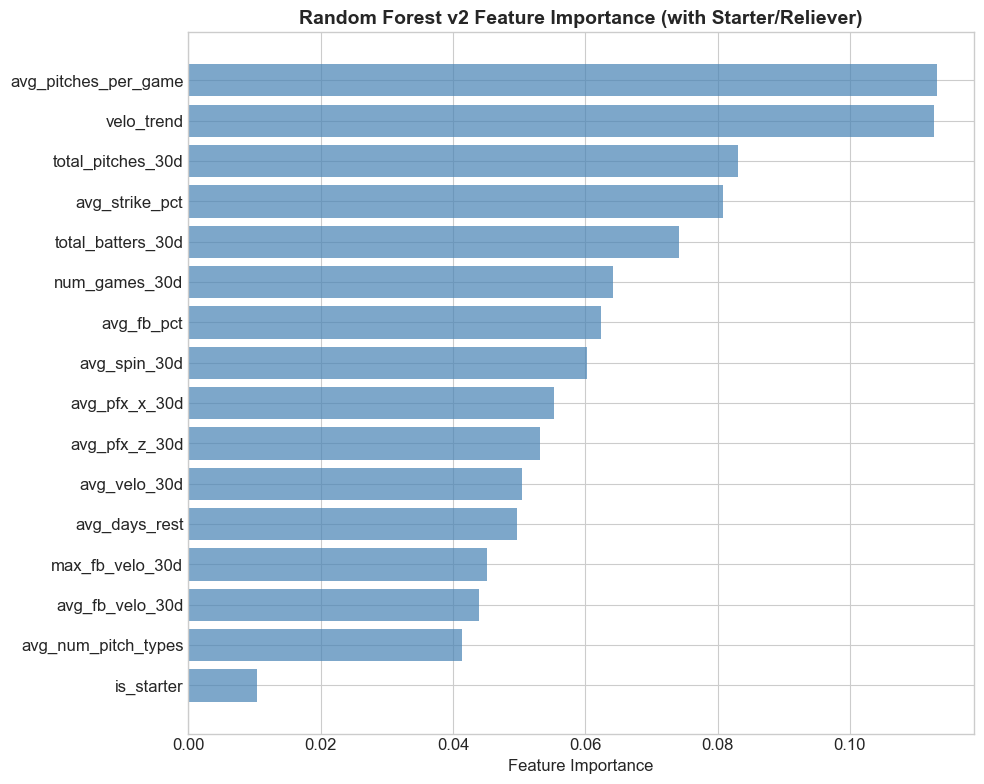

In [116]:
importance_v2 = pd.DataFrame({
    "feature": feature_cols_v2,
    "importance": rf_v2.feature_importances_
})
importance_v2 = importance_v2.sort_values("importance", ascending=False)

print("Random Forest v2 Feature Importance:")
print("-" * 55)
for i in range(len(importance_v2)):
    row = importance_v2.iloc[i]
    bar = "█" * int(row["importance"] * 100)
    print(f"  {row['feature']:<25} {row['importance']:.4f}  {bar}")

#Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(importance_v2)), importance_v2["importance"],
        color="steelblue", alpha=0.7)
ax.set_yticks(range(len(importance_v2)))
ax.set_yticklabels(importance_v2["feature"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest v2 Feature Importance (with Starter/Reliever)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/model_rf_v2_importance.png", dpi=150, bbox_inches="tight")
plt.show()

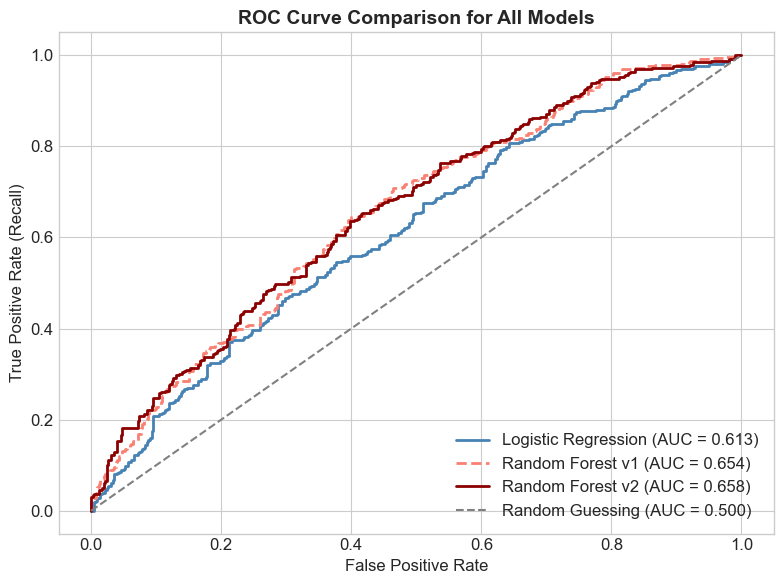


Full Model Comparison:
Metric                       Log. Reg.        RF v1        RF v2
-----------------------------------------------------------------
Test AUC-ROC                    0.6132       0.6541       0.6582
CV Mean AUC-ROC                      —       0.6516       0.6578


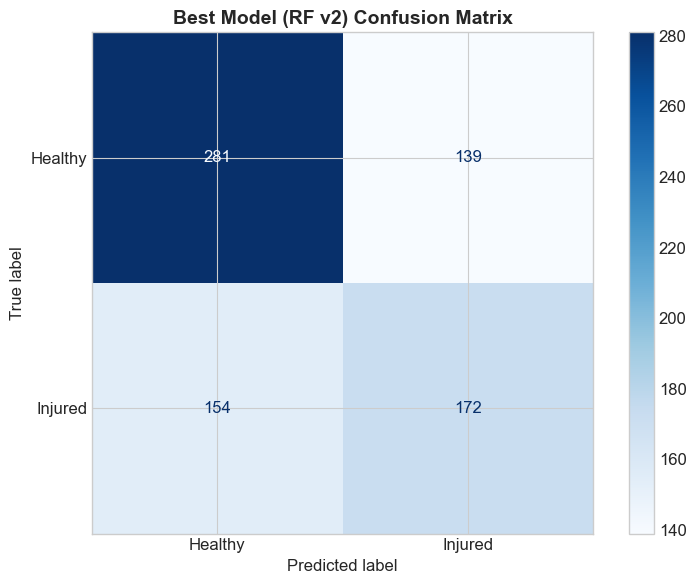

In [118]:
#Retrain Logistic Regression with the is_starter feature
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test_v2)
lr_v2 = LogisticRegression(random_state=42, max_iter=1000)
lr_v2.fit(X_train_scaled_v2, y_train_v2)
y_proba_lr_v2 = lr_v2.predict_proba(X_test_scaled_v2)[:, 1]
auc_lr_v2 = roc_auc_score(y_test_v2, y_proba_lr_v2)

#ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 6))

#Logistic Regression v2
fpr_lr, tpr_lr, _ = roc_curve(y_test_v2, y_proba_lr_v2)
ax.plot(fpr_lr, tpr_lr, color="steelblue", linewidth=2,
        label=f"Logistic Regression (AUC = {auc_lr_v2:.3f})")

#Random Forest v1 (original)
fpr_rf1, tpr_rf1, _ = roc_curve(y_test, y_pred_proba_rf)
ax.plot(fpr_rf1, tpr_rf1, color="salmon", linewidth=2, linestyle="--",
        label=f"Random Forest v1 (AUC = {auc_rf:.3f})")

#Random Forest v2 (with starter feature)
fpr_rf2, tpr_rf2, _ = roc_curve(y_test_v2, y_pred_proba_v2)
ax.plot(fpr_rf2, tpr_rf2, color="darkred", linewidth=2,
        label=f"Random Forest v2 (AUC = {auc_v2:.3f})")

#Random baseline
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
        label="Random Guessing (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve Comparison for All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("data/raw/model_comparison_all_roc.png", dpi=150, bbox_inches="tight")
plt.show()

#summary table
print("\nFull Model Comparison:")
print("=" * 65)
print(f"{'Metric':<25} {'Log. Reg.':>12} {'RF v1':>12} {'RF v2':>12}")
print("-" * 65)
print(f"{'Test AUC-ROC':<25} {auc_lr_v2:>12.4f} {auc_rf:>12.4f} {auc_v2:>12.4f}")
print(f"{'CV Mean AUC-ROC':<25} {'—':>12} {cv_scores_rf.mean():>12.4f} {cv_scores_v2.mean():>12.4f}")

# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_v2, y_pred_v2,
    display_labels=["Healthy", "Injured"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Best Model (RF v2) Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/raw/model_best_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [120]:
#save the final modeling dataset with the starter feature
modeling_df.to_csv("data/raw/modeling_dataset_final.csv", index=False)
print("Final dataset saved: data/raw/modeling_dataset_final.csv")

Final dataset saved: data/raw/modeling_dataset_final.csv


Three models were trained and evaluated. Logistic Regression was our interpretable baseline with a test AUC of 0.6132. Then, Random Forest improved on that with a test AUC of 0.6541 and a cross-validated AUC of 0.6516, which suggested non-linear patterns and feature interactions. Next, I decided to add a starter/reliever classification, which gave us the best performance with a test AUC of 0.6582 and a cross-validated AUC of 0.6578. The consistency between test and cross-validation scores across all models mean the results are stable and not just a luck. 